In [55]:
import pandas as pd
import numpy as np
from datetime import timedelta
import glob
import os
import matplotlib.pyplot as plt
import re
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,brier_score_loss


In [56]:
### === STEP 1: 数据加载与合并 === ###
# 指定路径（替换为你的路径）
match_path = "D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw/"  # 包含 wta_matches_XXXX.csv 和 wta_matches_qual_itf_XXXX.csv
rank_path = match_path  # 包含 wta_rankings_XXXX.csv 和 wta_rankings_current.csv

In [57]:
import glob, os

print("Looking in:", match_path)
match_files = glob.glob(os.path.join(match_path, "wta_matches*.csv"))
print("Found files:", match_files)

Looking in: D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw/
Found files: ['D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1968.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1969.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1970.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1971.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1972.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/raw\\wta_matches_1973.csv', 'D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/ra

In [58]:
# 读取所有比赛数据（主赛 + 资格赛）
match_files = glob.glob(os.path.join(match_path, "wta_matches*.csv"))
match_dfs = [pd.read_csv(f, low_memory=False) for f in match_files]
all_matches = pd.concat(match_dfs, ignore_index=True)

In [59]:
# 读取 player 文件
all_players = pd.read_csv(match_path + "wta_players.csv")

print(all_players.head())

   player_id name_first name_last hand         dob  ioc  height wikidata_id
0     113190      Bobby     Riggs    U         NaN  USA     NaN         NaN
1     200000          X         X    U  19000000.0  UNK     NaN         NaN
2     200001    Martina    Hingis    R  19800930.0  SUI   170.0     Q134720
3     200002    Mirjana     Lucic    R  19820309.0  CRO   181.0     Q239686
4     200003    Justine     Henin    R  19820601.0  BEL   167.0      Q11682


C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\1509236970.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  all_players = pd.read_csv(match_path + "wta_players.csv")


In [192]:
# 读取所有排名数据
rank_files = glob.glob(os.path.join(rank_path, "wta_rankings*.csv"))
rank_dfs = [pd.read_csv(f) for f in rank_files]
all_ranks = pd.concat(rank_dfs, ignore_index=True)

In [60]:
# 从 tourney_date 提取年份（前四位），并转换为整数
all_matches['year'] = all_matches['tourney_date'].astype(str).str[:4].astype(int)

In [61]:
# 格式处理
all_matches["tourney_date"] = pd.to_datetime(all_matches["tourney_date"], format="%Y%m%d")

In [193]:
all_ranks["ranking_date"] = pd.to_datetime(all_ranks["ranking_date"], format="%Y%m%d")

In [62]:
# 先去掉小数点再转字符串，确保不会出错
all_players["dob"] = all_players["dob"].apply(lambda x: str(int(x)) if pd.notnull(x) else x)

# 转换为 datetime
all_players["dob"] = pd.to_datetime(all_players["dob"], format="%Y%m%d", errors="coerce")


In [63]:
# 提取年份，并筛选 2000 年及以后
all_matches = all_matches[all_matches['year'] >= 2010]

# 筛选比赛级别
selected_levels = ['G', 'P', 'PM','F','I','D','O']

filtered_matches = all_matches[all_matches['tourney_level'].isin(selected_levels)]

In [64]:
# distribution_percentage = filtered_matches['tourney_level'].value_counts(normalize=True) * 100
#
# print(distribution_percentage)

In [65]:
# 比赛等级标签
def clean_tourney_level(row):
    name = row['tourney_name']
    level = row['tourney_level']

    if 'Fed Cup' in name or 'BJK' in name:
        return 'Fed Cup'  # 国家队赛事（联合会杯）
    elif 'Olympic' in name:
        return 'Olympic'  # 奥运会
    elif level == 'D':
        return 'WTA 125'  # 默认认为 D 是 WTA125，如果没有其他特征
    elif level == 'I':
        return 'WTA 250'
    elif level == 'P':
        return 'WTA 500'
    elif level == 'PM':
        return 'WTA 1000'
    elif level == 'G':
        return 'Grand Slam'  # Grand Slam
    elif level == 'F':
        return 'Special Event'
    else:
        return 'Other'  # 异常值或未知

# 应用于 DataFrame
filtered_matches = filtered_matches.copy()
filtered_matches['tourney_level_name'] = filtered_matches.apply(clean_tourney_level, axis=1)

In [66]:
# 删除特殊赛事
filtered_matches = filtered_matches[
    ~filtered_matches['tourney_level_name'].isin(['Special Event', 'Other'])
]

In [67]:
# 添加 rank_group 分类函数
def assign_rank_group(row):
    ranks = [row['winner_rank'], row['loser_rank']]
    ranks = [r for r in ranks if not pd.isnull(r)]
    if not ranks:
        return 'unknown'
    avg_rank = np.mean(ranks)
    if avg_rank <= 30:
        return 'Top 30'
    elif avg_rank <= 100:
        return '31-100'
    elif avg_rank <= 200:
        return '101-200'
    else:
        return '201+'

# 确保有 rank_group 列
filtered_matches = filtered_matches.copy()
filtered_matches['rank_group'] = filtered_matches.apply(assign_rank_group, axis=1)

In [68]:
# score 处理
# Step 1: If the score field contains "RET" or "W/O", assign "RET" or "W/O" to a new variable called game_end_flg.
#
# Step 2: Split the score field into three separate columns — score_set1, score_set2, and score_set3 — using a space as the delimiter.
#
# Step 3: For each of the three score_set* columns, further split them using the hyphen (-) as the delimiter to extract score_set1_w and score_set1_l (representing games won and lost in set 1), and so on for set 2 and set 3.
#
# Step 4: Sum the three score_set*_w columns to generate a new variable games_won, and sum the three score_set*_l columns to generate games_lost. During the summing process, if any of the columns contain "(", extract the number between "(" and ")" and store it in a new column called tiebreaker_l_sc.
#
# Step 5: Add games_won and games_lost together to calculate the total number of games played, stored in a new variable called games_played.

In [69]:
# 先把 "DEF" 和 "def." 统一替换为 "RET"
filtered_matches['score_cp'] = filtered_matches['score'].str.replace(r'\bdef\.?\b', 'RET', flags=re.IGNORECASE, regex=True)

# 第一步：提取 game_end_flg 并清洗 score 字段
filtered_matches['game_end_flg'] = filtered_matches['score_cp'].apply(
    lambda x: 'RET' if 'RET' in str(x) else ('W/O' if 'W/O' in str(x) else np.nan)
)
filtered_matches['score_cp'] = filtered_matches['score_cp'].str.replace('RET', '', regex=False)
filtered_matches['score_cp'] = filtered_matches['score_cp'].str.replace('W/O', '', regex=False)

# 最后：去除所有其他非比分字符，只保留数字、括号、空格和破折号
filtered_matches['score_cp'] = filtered_matches['score_cp'].str.replace(r'[^0-9\-\(\) ]+', '', regex=True)

# 去除首尾空格
filtered_matches['score_cp'] = filtered_matches['score_cp'].str.strip()


# 第二步：按空格拆分为三个set列
score_sets = filtered_matches['score_cp'].str.split(' ', expand=True)
score_sets.columns = ['score_set1', 'score_set2', 'score_set3']
filtered_matches = pd.concat([filtered_matches, score_sets], axis=1)

matchups = filtered_matches[
    filtered_matches["game_end_flg"] == "RET"
][["score", "game_end_flg", 'score_set1', 'score_set2', 'score_set3']]


In [70]:
# 第三步：再按 "-" 拆分为胜方/负方得分
for i in range(1, 4):
    set_col = f'score_set{i}'
    win_col = f'score_set{i}_w'
    lose_col = f'score_set{i}_l'

    # 用正则拆分，保留括号中的内容用于后续处理
    split_scores = filtered_matches[set_col].str.extract(r'(\d+)\-([\d\(\)]+)')
    filtered_matches[win_col] = split_scores[0]
    filtered_matches[lose_col] = split_scores[1]

In [71]:
# 第四步：处理括号并求和
def extract_tiebreak(score):
    match = re.search(r'\((\d+)\)', str(score))
    return int(match.group(1)) if match else np.nan

def clean_score(score):
    return re.sub(r'\(\d+\)', '', str(score))

tiebreakers = []
games_won = []
games_lost = []

for i in range(1, 4):
    win_col = f'score_set{i}_w'
    lose_col = f'score_set{i}_l'
    tiebreak_col = f'tiebreaker_set{i}_l'

    # 提取tiebreak
    filtered_matches[tiebreak_col] = filtered_matches[lose_col].apply(extract_tiebreak)
    tiebreakers.append(tiebreak_col)

    # 清除括号再转为整数
    filtered_matches[win_col] = pd.to_numeric(filtered_matches[win_col], errors='coerce')
    filtered_matches[lose_col] = filtered_matches[lose_col].apply(clean_score)
    filtered_matches[lose_col] = pd.to_numeric(filtered_matches[lose_col], errors='coerce')

    games_won.append(win_col)
    games_lost.append(lose_col)

# 总结得分
filtered_matches['games_won'] = filtered_matches[games_won].sum(axis=1, skipna=True)
filtered_matches['games_lost'] = filtered_matches[games_lost].sum(axis=1, skipna=True)

In [72]:
# 第五步：总比较局数
filtered_matches['games_played'] = filtered_matches['games_won'] + filtered_matches['games_lost']

In [73]:
# 计算抢七的合计分数
tiebreaker_cols = ['tiebreaker_set1_l', 'tiebreaker_set2_l', 'tiebreaker_set3_l']

# 定义转换逻辑
def compute_tiebreaker_l_sc(row):
    total = 0
    for col in tiebreaker_cols:
        val = row[col]
        if pd.notna(val):
            if val < 5:
                total += val + 7
            else:
                total += val * 2 + 2
    return total if total > 0 else np.nan  # 若总和为0则设为NaN

# 应用到DataFrame
filtered_matches['tiebreaker_l_sc'] = filtered_matches.apply(compute_tiebreaker_l_sc, axis=1)

In [74]:
# **minutes inputation**
# Step 1:
# To impute missing values in the minutes field, first calculate the average minutes per game.
# Filter out all records where minutes is greater than 0, then divide minutes by games_played to compute minutes_per_g.
# Calculate the median of minutes_per_g, round it to the nearest integer, and store it as minutes_mid_per_g.
#
# Step 2:
# For records where minutes is null, fill the missing value with minutes_mid_per_g multiplied by games_played.

In [75]:
# 第一步：计算平均每局耗时（minutes_per_g）
# 将 minutes > 500 的记录设置为 NaN
filtered_matches.loc[filtered_matches['minutes'] > 500, 'minutes'] = np.nan
# 只取 minutes > 0 且 games_played > 0 的记录
valid_minutes = filtered_matches[(filtered_matches['minutes'] > 0) & (filtered_matches['games_played'] > 0)].copy()

# 计算每局耗时
valid_minutes['minutes_per_g'] = valid_minutes['minutes'] / valid_minutes['games_played']

In [76]:
# 计算中位数，并四舍五入为整数
minutes_mid_per_g = round(valid_minutes['minutes_per_g'].median())

print(f"(minutes_mid_per_g)：{minutes_mid_per_g} mins")

(minutes_mid_per_g)：4 mins


In [77]:
# 第二步：填补 minutes 为空的记录
def fill_minutes(row):
    if pd.isna(row['minutes']):
        if pd.notna(row['tiebreaker_l_sc']) and row['tiebreaker_l_sc'] > 0:
            return round((row['tiebreaker_l_sc'] - 7) / 5 + minutes_mid_per_g * row['games_played'])
        else:
            return round(minutes_mid_per_g * row['games_played'])
    else:
        return row['minutes']

filtered_matches['minutes'] = filtered_matches.apply(fill_minutes, axis=1)


In [78]:
# round-encoding
# 决赛为1，越外围数字越大
round_mapping = {
    'F': 1,
    'BR': 1,
    'SF': 2,
    'QF': 3,
    'R16': 4,
    'R32': 5,
    'R64': 6,
    'R128': 7,
    'Q3': 8,
    'Q2': 9,
    'Q1': 10,
    'RR': 4
}

# 更新round_code
filtered_matches['round_code'] = filtered_matches['round'].map(round_mapping)


In [79]:
# 计算排名差和积分差
filtered_matches['rank_diff_w'] = filtered_matches['winner_rank'] - filtered_matches['loser_rank']
filtered_matches['rank_diff_l'] = filtered_matches['loser_rank'] - filtered_matches['winner_rank']

filtered_matches['points_diff_w'] = filtered_matches['winner_rank_points'] - filtered_matches['loser_rank_points']
filtered_matches['points_diff_l'] = filtered_matches['loser_rank_points'] - filtered_matches['winner_rank_points']


In [80]:
# Player lever table
# 从比赛记录表里把winner和loser信息分别取出来，创建出一个player_id + match_id(tourney_id+match_num)为联合主键的表，同一场比赛会因为两个球员的视角，在这个表有两条记录

In [81]:
# 需要提取的变量和对应新变量名
rename_columns = {
    'loser_id': 'player_id',
    'loser_seed': 'player_seed',
    'loser_entry': 'player_entry',
    'loser_name': 'player_name',
    'loser_hand': 'player_hand',
    'loser_ht': 'player_ht',
    'loser_ioc': 'player_ioc',
    'loser_age': 'player_age',
    'winner_id': 'opponent_id',
    'winner_seed': 'opponent_seed',
    'l_ace': 'ace',
    'l_df': 'df',
    'l_svpt': 'svpt',
    'l_1stIn': '1stIn',
    'l_1stWon': '1stWon',
    'l_2ndWon': '2ndWon',
    'l_SvGms': 'SvGms',
    'l_bpSaved': 'bpSaved',
    'l_bpFaced': 'bpFaced',
    'loser_rank': 'rank',
    'loser_rank_points': 'rank_points',
    'rank_diff_l':'rank_diff',
    'points_diff_l':'points_diff'
}

# 需要保留的所有变量
selected_columns = [
    'tourney_id','tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date',
    'match_num', 'year', 'rank_group', 'loser_id', 'loser_seed', 'loser_entry',
    'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'winner_id', 'winner_seed','score',
    'round_code', 'minutes', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon',
    'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'loser_rank', 'loser_rank_points',
    'game_end_flg', 'games_lost', 'games_played', 'tiebreaker_l_sc','rank_diff_l','points_diff_l'
]

# 筛选并重命名
lost_matches = filtered_matches[selected_columns].rename(columns=rename_columns)

# 添加 result 列
lost_matches['result'] = 'lost'


In [82]:
# 胜利者视角：需要提取的变量和对应新变量名
rename_columns_won = {
    'winner_id': 'player_id',
    'winner_seed': 'player_seed',
    'winner_entry': 'player_entry',
    'winner_name': 'player_name',
    'winner_hand': 'player_hand',
    'winner_ht': 'player_ht',
    'winner_ioc': 'player_ioc',
    'winner_age': 'player_age',
    'loser_id': 'opponent_id',
    'loser_seed': 'opponent_seed',
    'w_ace': 'ace',
    'w_df': 'df',
    'w_svpt': 'svpt',
    'w_1stIn': '1stIn',
    'w_1stWon': '1stWon',
    'w_2ndWon': '2ndWon',
    'w_SvGms': 'SvGms',
    'w_bpSaved': 'bpSaved',
    'w_bpFaced': 'bpFaced',
    'winner_rank': 'rank',
    'winner_rank_points': 'rank_points',
    'games_won': 'games_won',
    'rank_diff_w':'rank_diff',
    'points_diff_w':'points_diff'
}

# 需要保留的所有变量
selected_columns_won = [
    'tourney_id','tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date',
    'match_num', 'year', 'rank_group', 'winner_id', 'winner_seed', 'winner_entry',
    'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed','score',
    'round_code', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon',
    'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'winner_rank', 'winner_rank_points',
    'games_won', 'games_played', 'tiebreaker_l_sc','rank_diff_w','points_diff_w'
]

# 筛选并重命名
won_matches = filtered_matches[selected_columns_won].rename(columns=rename_columns_won)

# 添加 result 列
won_matches['result'] = 'won'

In [83]:
# 合并 lost_matches 和 won_matches
player_matches = pd.concat([lost_matches, won_matches], axis=0, ignore_index=True)

In [84]:
# Elo rating

In [85]:
# filtered_matches 已经准备好，且包含如下重要字段：
# winner_id, loser_id, tourney_date, surface, games_won, games_lost, games_played, match_num

# 按比赛时间排序（加match_num保证稳定顺序）
filtered_matches = filtered_matches.sort_values(['tourney_date', 'match_num']).reset_index(drop=True)

# ELO参数
K_FACTOR = 32
initial_elo = 1500

# 获取所有参与的球员ID
all_players = set(filtered_matches['winner_id']).union(set(filtered_matches['loser_id']))

# 初始化elo字典
elo_dict = {}
for pid in all_players:
    elo_dict[pid] = {
        'elo_rating': initial_elo,
        'elo_rating_wt1': initial_elo,
        'elo_hard': initial_elo,
        'elo_clay': initial_elo,
        'elo_grass': initial_elo,
        'elo_wt1_hard': initial_elo,
        'elo_wt1_clay': initial_elo,
        'elo_wt1_grass': initial_elo
    }

# 记录赛前ELO值的列表（比赛级别）
elo_pre_records = []

# 记录每场比赛后球员ELO历史的列表（球员级别）
player_elo_history = []

# 定义ELO期望胜率函数
def expected_score(player_elo, opponent_elo):
    return 1 / (1 + 10 ** ((opponent_elo - player_elo) / 400))

# ELO 更新主循环
for idx, row in filtered_matches.iterrows():
    winner_id = row['winner_id']
    loser_id = row['loser_id']
    date = row['tourney_date']
    surface = row['surface']
    if pd.isna(surface):
        surface = 'hard'
    else:
        surface = surface.lower()
    if surface == 'carpet' or surface not in ['hard', 'clay', 'grass']:
        surface = 'hard'

    # ELO键
    winner_surface_key = f"elo_{surface}"
    loser_surface_key = f"elo_{surface}"
    winner_surface_wt1_key = f"elo_wt1_{surface}"
    loser_surface_wt1_key = f"elo_wt1_{surface}"

    # 当前ELO（赛前）
    winner_elo = elo_dict[winner_id]['elo_rating']
    loser_elo = elo_dict[loser_id]['elo_rating']
    winner_elo_wt1 = elo_dict[winner_id]['elo_rating_wt1']
    loser_elo_wt1 = elo_dict[loser_id]['elo_rating_wt1']
    winner_surface_elo = elo_dict[winner_id][winner_surface_key]
    loser_surface_elo = elo_dict[loser_id][loser_surface_key]
    winner_surface_elo_wt1 = elo_dict[winner_id][winner_surface_wt1_key]
    loser_surface_elo_wt1 = elo_dict[loser_id][loser_surface_wt1_key]

    # 计算期望胜率
    expected_win_winner = expected_score(winner_elo, loser_elo)
    expected_win_surface = expected_score(winner_surface_elo, loser_surface_elo)
    expected_win_elo_wt1 = expected_score(winner_elo_wt1, loser_elo_wt1)
    expected_win_surface_wt1 = expected_score(winner_surface_elo_wt1, loser_surface_elo_wt1)

    # 赛前ELO和期望胜率保存（比赛级别）
    elo_pre_records.append({
        'winner_elo_pre': winner_elo,
        'loser_elo_pre': loser_elo,
        'winner_elo_wt1_pre': winner_elo_wt1,
        'loser_elo_wt1_pre': loser_elo_wt1,
        'winner_surface_elo_pre': winner_surface_elo,
        'loser_surface_elo_pre': loser_surface_elo,
        'winner_surface_elo_wt1_pre': winner_surface_elo_wt1,
        'loser_surface_elo_wt1_pre': loser_surface_elo_wt1,
        'expected_win_elo': expected_win_winner,
        'expected_win_surface': expected_win_surface,
        'expected_win_elo_wt1': expected_win_elo_wt1,
        'expected_win_surface_wt1': expected_win_surface_wt1
    })

    # 读取比赛相关的局数数据，防止除0
    games_won = row.get('games_won', 1)
    games_lost = row.get('games_lost', 1)
    games_played = row.get('games_played', 1)
    if pd.isna(games_played) or games_played == 0:
        games_played = 1
    if pd.isna(games_won) or games_won == 0:
        games_won = 1
    if pd.isna(games_lost) or games_lost == 0:
        games_lost = 1

    # ELO更新计算
    winner_elo_new = winner_elo + K_FACTOR * (1 - expected_win_winner)
    loser_elo_new = loser_elo + K_FACTOR * (0 - expected_win_winner)
    winner_elo_wt1_new = winner_elo_wt1 + K_FACTOR * (1 - expected_win_winner) * (games_won / games_played)
    loser_elo_wt1_new = loser_elo_wt1 + K_FACTOR * (0 - expected_win_winner) * (games_lost / games_played)
    winner_surface_elo_new = winner_surface_elo + K_FACTOR * (1 - expected_win_surface)
    loser_surface_elo_new = loser_surface_elo + K_FACTOR * (0 - expected_win_surface)
    winner_surface_elo_wt1_new = winner_surface_elo_wt1 + K_FACTOR * (1 - expected_win_surface) * (games_won / games_played)
    loser_surface_elo_wt1_new = loser_surface_elo_wt1 + K_FACTOR * (0 - expected_win_surface) * (games_lost / games_played)

    # 更新 elo_dict
    elo_dict[winner_id].update({
        'elo_rating': winner_elo_new,
        'elo_rating_wt1': winner_elo_wt1_new,
        winner_surface_key: winner_surface_elo_new,
        winner_surface_wt1_key: winner_surface_elo_wt1_new
    })
    elo_dict[loser_id].update({
        'elo_rating': loser_elo_new,
        'elo_rating_wt1': loser_elo_wt1_new,
        loser_surface_key: loser_surface_elo_new,
        loser_surface_wt1_key: loser_surface_elo_wt1_new
    })

    # 赛后记录球员ELO历史（球员级别）
    player_elo_history.append({
        'player_id': winner_id,
        'date': date,
        'elo_rating': elo_dict[winner_id]['elo_rating'],
        'elo_rating_wt1': elo_dict[winner_id]['elo_rating_wt1'],
        'elo_hard': elo_dict[winner_id]['elo_hard'],
        'elo_clay': elo_dict[winner_id]['elo_clay'],
        'elo_grass': elo_dict[winner_id]['elo_grass'],
        'elo_wt1_hard': elo_dict[winner_id]['elo_wt1_hard'],
        'elo_wt1_clay': elo_dict[winner_id]['elo_wt1_clay'],
        'elo_wt1_grass': elo_dict[winner_id]['elo_wt1_grass'],
    })
    player_elo_history.append({
        'player_id': loser_id,
        'date': date,
        'elo_rating': elo_dict[loser_id]['elo_rating'],
        'elo_rating_wt1': elo_dict[loser_id]['elo_rating_wt1'],
        'elo_hard': elo_dict[loser_id]['elo_hard'],
        'elo_clay': elo_dict[loser_id]['elo_clay'],
        'elo_grass': elo_dict[loser_id]['elo_grass'],
        'elo_wt1_hard': elo_dict[loser_id]['elo_wt1_hard'],
        'elo_wt1_clay': elo_dict[loser_id]['elo_wt1_clay'],
        'elo_wt1_grass': elo_dict[loser_id]['elo_wt1_grass'],
    })

# 赛前ELO快照转DataFrame（比赛级别）
elo_pre_df = pd.DataFrame(elo_pre_records)

# 和 filtered_matches 合并
filtered_matches = pd.concat([filtered_matches.reset_index(drop=True), elo_pre_df], axis=1)

# 球员ELO历史转DataFrame（球员级别）
player_elo_history_df = pd.DataFrame(player_elo_history)
player_elo_history_df = player_elo_history_df.sort_values(['player_id', 'date']).reset_index(drop=True)

# 此时你有：
# 1) filtered_matches 包含赛前ELO和期望胜率（不变）
# 2) player_elo_history_df 是每位球员每场比赛后ELO历史，方便后续查询和分析



In [86]:
# 导出 player_elo_history_df
player_elo_history_df.to_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/player_elo_history_df.csv', index=False)

In [87]:
# 比赛数据衍生变量

In [88]:
# 最近n场比赛的技术统计数据
# 先排序
player_matches = player_matches.sort_values(['player_id', 'tourney_date', 'match_num']).copy()

# 定义通用函数：最近 N 场比赛的滚动平均
def rolling_mean_last_n_matches(df, col, n):
    return df.groupby('player_id')[col].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())

# 要处理的列
cols_to_derive = ['ace', 'df', '1stIn', '1stWon', 'SvGms', 'svpt', 'bpFaced', 'bpSaved']

# N 场比赛窗口
match_windows = [5, 10]

# 对每列进行处理
for col in cols_to_derive:
    for n in match_windows:
        new_col_name = f'{col}_avg_last_{n}_matches'
        player_matches[new_col_name] = rolling_mean_last_n_matches(player_matches, col, n)



In [89]:
# 最近N天内的技术统计数据衍生

tqdm.pandas()

# 定义通用函数：最近 N 天的滚动平均
def compute_rolling_mean_days(df, col, days):
    df = df.sort_values('tourney_date').copy()
    values = []
    for i, row in df.iterrows():
        date = row['tourney_date']
        mask = (df['tourney_date'] < date) & (df['tourney_date'] >= date - pd.Timedelta(days=days))
        val = df.loc[mask, col].mean()
        values.append(val)
    return values

# N 天时间窗口
day_windows = [30, 90, 180, 365]

# 对每列进行处理
for col in cols_to_derive:
    for days in day_windows:
        new_col_name = f'{col}_avg_last_{days}_days'
        player_matches[new_col_name] = (
            player_matches
            .groupby('player_id', group_keys=False)
            .progress_apply(lambda df: pd.Series(compute_rolling_mean_days(df, col, days), index=df.index))
        )


100%|██████████| 2462/2462 [00:47<00:00, 51.95it/s] 


In [90]:
# Fatige & Momentum

In [91]:
# 本次 tourney_id 的前几场比赛总时长（minutes）
def minutes_sum_previous_matches_in_tourney(df):
    df = df.copy()
    df['minutes_prev_matches_in_tourney'] = (
        df.groupby(['player_id', 'tourney_id'])['minutes']
        .transform(lambda x: x.cumsum().shift(1).fillna(0))
    )
    return df

player_matches = minutes_sum_previous_matches_in_tourney(player_matches)


In [92]:
 # 最近 7、15、30 天内的 minutes 总和
def sum_minutes_last_days(df, days):
    df = df.sort_values('tourney_date').copy()
    values = []
    for i, row in df.iterrows():
        date = row['tourney_date']
        mask = (df['tourney_date'] < date) & (df['tourney_date'] >= date - pd.Timedelta(days=days))
        values.append(df.loc[mask, 'minutes'].sum())
    return values

for d in [7, 15, 30]:
    col = f'minutes_sum_last_{d}_days'
    player_matches[col] = (
        player_matches.groupby('player_id', group_keys=False)
        .progress_apply(lambda df: pd.Series(sum_minutes_last_days(df, d), index=df.index))
    )


100%|██████████| 2462/2462 [00:45<00:00, 53.65it/s] 


In [93]:
# 最近 7/14/30 天内的比赛次数
def count_matches_last_days(df, days):
    df = df.sort_values('tourney_date').copy()
    counts = []
    for i, row in df.iterrows():
        date = row['tourney_date']
        mask = (df['tourney_date'] < date) & (df['tourney_date'] >= date - pd.Timedelta(days=days))
        counts.append(mask.sum())
    return counts

for d in [7, 14, 30]:
    col = f'match_count_last_{d}_days'
    player_matches[col] = (
        player_matches.groupby('player_id', group_keys=False)
        .progress_apply(lambda df: pd.Series(count_matches_last_days(df, d), index=df.index))
    )


100%|██████████| 2462/2462 [00:30<00:00, 80.23it/s] 


In [94]:
# 连胜场次 / 连败场次
def compute_streaks(df):
    df = df.copy()
    df['winning_streak'] = 0
    df['losing_streak'] = 0

    for pid, group in df.groupby('player_id'):
        streak = 0
        losing_streak = 0
        results = group['result'].values
        indices = group.index

        for i in range(len(results)):
            if i == 0:
                df.at[indices[i], 'winning_streak'] = 0
                df.at[indices[i], 'losing_streak'] = 0
                continue

            if results[i - 1] == 'won':
                streak += 1
                losing_streak = 0
            elif results[i - 1] == 'lost':
                losing_streak += 1
                streak = 0
            else:
                streak = losing_streak = 0

            df.at[indices[i], 'winning_streak'] = streak
            df.at[indices[i], 'losing_streak'] = losing_streak

    return df

player_matches = compute_streaks(player_matches)


In [95]:
# 最近 5 场、10 场比赛的胜率
def rolling_win_rate(df, n):
    df = df.copy()
    results = df['result'].eq('won').astype(int)
    df[f'win_rate_last_{n}_matches'] = results.shift(1).rolling(n, min_periods=1).mean()
    return df

for n in [5, 10]:
    player_matches = (
        player_matches
        .groupby('player_id', group_keys=False)
        .apply(lambda df: rolling_win_rate(df, n))
    )

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\611981058.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: rolling_win_rate(df, n))
C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\611981058.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: rolling_win_rate(df, n))


In [96]:
# 上一场比赛中，games_won 占 games_played 的百分比
player_matches['last_match_games_ratio'] = (
    player_matches
    .groupby('player_id')['games_won']
    .shift(1) / player_matches
    .groupby('player_id')['games_played']
    .shift(1)
)

In [97]:
# H2H 统计函数

In [98]:
player_matches = player_matches.sort_values(['player_id', 'tourney_date']).reset_index(drop=True)

def h2h_stats_one_direction(row, df, days=None, surface=None):
    pid, oid, date = row['player_id'], row['opponent_id'], row['tourney_date']

    # 只保留 player_id vs opponent_id 的比赛（单向匹配）
    mask = (df['player_id'] == pid) & (df['opponent_id'] == oid) & (df['tourney_date'] < date)

    if days is not None:
        mask &= (df['tourney_date'] >= date - pd.Timedelta(days=days))
    if surface is not None:
        mask &= (df['surface'] == surface)

    h2h_df = df.loc[mask]

    total_played = len(h2h_df)
    total_wins = (h2h_df['result'] == 'won').sum()
    win_rate = total_wins / total_played if total_played > 0 else None

    return pd.Series([total_played, win_rate])

# 所有组合：时间窗口 × 场地
time_windows = [None, 180, 365]   # None 表示历史所有
surfaces = [None, 'Hard', 'Clay', 'Grass']

for days in time_windows:
    for surface in surfaces:
        label = ''
        if days is None:
            label += 'all'
        else:
            label += f'{days}d'
        if surface is not None:
            label += f'_{surface}'

        col_played = f'h2h_total_played_{label}'
        col_winrate = f'h2h_win_rate_total_{label}'

        player_matches[[col_played, col_winrate]] = (
            player_matches
            .progress_apply(lambda row: h2h_stats_one_direction(row, player_matches, days=days, surface=surface), axis=1)
        )

100%|██████████| 122540/122540 [14:11<00:00, 143.87it/s]


In [ ]:
# 数据合并

In [99]:
from collections import Counter

# 原始字段列表
original_columns = [
    'tourney_id', 'match_num',
    'winner_id', 'winner_seed', 'winner_entry', 'winner_name',
    'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
    'loser_id',
    'winner_elo_pre', 'loser_elo_pre',
    'winner_elo_wt1_pre', 'loser_elo_wt1_pre',
    'winner_surface_elo_pre', 'loser_surface_elo_pre',
    'winner_surface_elo_wt1_pre', 'loser_surface_elo_wt1_pre',
]

# 从后向前遍历，只保留最后一次出现的列
seen = set()
columns_to_keep = []
for col in reversed(original_columns):
    if col not in seen:
        seen.add(col)
        columns_to_keep.insert(0, col)  # 保持原始顺序

# 保留这些列，生成新 DataFrame
filtered_matches_subset = filtered_matches[columns_to_keep].copy()


In [100]:
print(filtered_matches_subset.columns.tolist())

['tourney_id', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'winner_elo_pre', 'loser_elo_pre', 'winner_elo_wt1_pre', 'loser_elo_wt1_pre', 'winner_surface_elo_pre', 'loser_surface_elo_pre', 'winner_surface_elo_wt1_pre', 'loser_surface_elo_wt1_pre']


In [101]:
columns_to_drop = [
    'tourney_level', 'rank_group', 'score', 'minutes', 'ace', 'df', 'svpt',
    '1stIn', '1stWon', '2ndWon', 'SvGms', 'bpSaved', 'bpFaced',
    'game_end_flg', 'games_lost', 'games_played', 'tiebreaker_l_sc', 'games_won'
]

# 生成一个新的 DataFrame
player_matches_cleaned = player_matches.drop(columns=columns_to_drop)

In [102]:
print(player_matches_cleaned.columns.tolist())

['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_date', 'match_num', 'year', 'player_id', 'player_seed', 'player_entry', 'player_name', 'player_hand', 'player_ht', 'player_ioc', 'player_age', 'opponent_id', 'opponent_seed', 'round_code', 'rank', 'rank_points', 'rank_diff', 'points_diff', 'result', 'ace_avg_last_5_matches', 'ace_avg_last_10_matches', 'df_avg_last_5_matches', 'df_avg_last_10_matches', '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches', '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches', 'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches', 'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches', 'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches', 'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches', 'ace_avg_last_30_days', 'ace_avg_last_90_days', 'ace_avg_last_180_days', 'ace_avg_last_365_days', 'df_avg_last_30_days', 'df_avg_last_90_days', 'df_avg_last_180_days', 'df_avg_last_365_days', '1stIn_avg_last_30_days', '1stIn_avg_las

In [103]:
# 首先分别处理 result == 'won' 和 result == 'lost' 的两部分

# result == 'won' 时的 merge
won_merge = player_matches_cleaned[player_matches_cleaned['result'] == 'won'].merge(
    filtered_matches_subset,
    how='left',
    left_on=['tourney_id', 'match_num', 'player_id', 'opponent_id'],
    right_on=['tourney_id', 'match_num', 'winner_id', 'loser_id'],
    suffixes=('', '_merged')
)

# result == 'lost' 时的 merge
lost_merge = player_matches_cleaned[player_matches_cleaned['result'] == 'lost'].merge(
    filtered_matches_subset,
    how='left',
    left_on=['tourney_id', 'match_num', 'player_id', 'opponent_id'],
    right_on=['tourney_id', 'match_num', 'loser_id', 'winner_id'],
    suffixes=('', '_merged')
)

# 合并结果
player_matches_merged = pd.concat([won_merge, lost_merge], axis=0).sort_index().reset_index(drop=True)


In [104]:
# 查看所有列名
print(player_matches_merged.columns.tolist())

['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_date', 'match_num', 'year', 'player_id', 'player_seed', 'player_entry', 'player_name', 'player_hand', 'player_ht', 'player_ioc', 'player_age', 'opponent_id', 'opponent_seed', 'round_code', 'rank', 'rank_points', 'rank_diff', 'points_diff', 'result', 'ace_avg_last_5_matches', 'ace_avg_last_10_matches', 'df_avg_last_5_matches', 'df_avg_last_10_matches', '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches', '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches', 'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches', 'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches', 'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches', 'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches', 'ace_avg_last_30_days', 'ace_avg_last_90_days', 'ace_avg_last_180_days', 'ace_avg_last_365_days', 'df_avg_last_30_days', 'df_avg_last_90_days', 'df_avg_last_180_days', 'df_avg_last_365_days', '1stIn_avg_last_30_days', '1stIn_avg_las

In [105]:
# 需要的列
opponent_cols = [
    'tourney_id', 'match_num', 'player_id', 'opponent_id',
    'player_hand', 'player_ht', 'player_age',
    'ace_avg_last_5_matches', 'ace_avg_last_10_matches',
    'df_avg_last_5_matches', 'df_avg_last_10_matches',
    '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches',
    '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches',
    'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches',
    'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches',
    'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches',
    'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches',
    'ace_avg_last_30_days', 'ace_avg_last_90_days',
    'ace_avg_last_180_days', 'ace_avg_last_365_days',
    'df_avg_last_30_days', 'df_avg_last_90_days',
    'df_avg_last_180_days', 'df_avg_last_365_days',
    '1stIn_avg_last_30_days', '1stIn_avg_last_90_days',
    '1stIn_avg_last_180_days', '1stIn_avg_last_365_days',
    '1stWon_avg_last_30_days', '1stWon_avg_last_90_days',
    '1stWon_avg_last_180_days', '1stWon_avg_last_365_days',
    'SvGms_avg_last_30_days', 'SvGms_avg_last_90_days',
    'SvGms_avg_last_180_days', 'SvGms_avg_last_365_days',
    'svpt_avg_last_30_days', 'svpt_avg_last_90_days',
    'svpt_avg_last_180_days', 'svpt_avg_last_365_days',
    'bpFaced_avg_last_30_days', 'bpFaced_avg_last_90_days',
    'bpFaced_avg_last_180_days', 'bpFaced_avg_last_365_days',
    'bpSaved_avg_last_30_days', 'bpSaved_avg_last_90_days',
    'bpSaved_avg_last_180_days', 'bpSaved_avg_last_365_days',
    'minutes_prev_matches_in_tourney', 'minutes_sum_last_7_days',
    'minutes_sum_last_15_days', 'minutes_sum_last_30_days',
    'match_count_last_7_days', 'match_count_last_14_days',
    'match_count_last_30_days', 'winning_streak', 'losing_streak',
    'win_rate_last_5_matches', 'win_rate_last_10_matches',
    'last_match_games_ratio'
]

# 1️⃣ 从 player_matches_merged 中取出 opponent_stat
opponent_stat = player_matches_merged[opponent_cols].copy()

# 2️⃣ 除关键 ID 列外加上 'opp_' 前缀
id_cols = ['tourney_id', 'match_num', 'player_id', 'opponent_id']
rename_dict = {col: f"opp_{col}" for col in opponent_stat.columns if col not in id_cols}
opponent_stat.rename(columns=rename_dict, inplace=True)

# 3️⃣ 合并
player_matches_merged = player_matches_merged.merge(
    opponent_stat,
    how='left',
    left_on=['tourney_id', 'match_num', 'opponent_id'],
    right_on=['tourney_id', 'match_num', 'player_id'],  # opponent 的 player_id
)

# 4️⃣ 删除 opponent_stat 多余的 ID 列
player_matches_merged.drop(columns=['player_id_y', 'opponent_id_y','winner_id','winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id'], inplace=True)

# 5️⃣ 修正合并后的列名（原 player_id_x 改回 player_id）
player_matches_merged.rename(columns={'player_id_x': 'player_id', 'opponent_id_x': 'opponent_id'}, inplace=True)


In [106]:
# 查看所有列名
print(player_matches_merged.columns.tolist())

['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_date', 'match_num', 'year', 'player_id', 'player_seed', 'player_entry', 'player_name', 'player_hand', 'player_ht', 'player_ioc', 'player_age', 'opponent_id', 'opponent_seed', 'round_code', 'rank', 'rank_points', 'rank_diff', 'points_diff', 'result', 'ace_avg_last_5_matches', 'ace_avg_last_10_matches', 'df_avg_last_5_matches', 'df_avg_last_10_matches', '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches', '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches', 'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches', 'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches', 'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches', 'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches', 'ace_avg_last_30_days', 'ace_avg_last_90_days', 'ace_avg_last_180_days', 'ace_avg_last_365_days', 'df_avg_last_30_days', 'df_avg_last_90_days', 'df_avg_last_180_days', 'df_avg_last_365_days', '1stIn_avg_last_30_days', '1stIn_avg_las

In [107]:
# 衍生出两个球员差异的变量
import numpy as np

# 你提供的player变量列表
player_vars = [
    'player_age',
    'ace_avg_last_5_matches', 'ace_avg_last_10_matches',
    'df_avg_last_5_matches', 'df_avg_last_10_matches',
    '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches',
    '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches',
    'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches',
    'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches',
    'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches',
    'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches',
    'ace_avg_last_30_days', 'ace_avg_last_90_days',
    'ace_avg_last_180_days', 'ace_avg_last_365_days',
    'df_avg_last_30_days', 'df_avg_last_90_days',
    'df_avg_last_180_days', 'df_avg_last_365_days',
    '1stIn_avg_last_30_days', '1stIn_avg_last_90_days',
    '1stIn_avg_last_180_days', '1stIn_avg_last_365_days',
    '1stWon_avg_last_30_days', '1stWon_avg_last_90_days',
    '1stWon_avg_last_180_days', '1stWon_avg_last_365_days',
    'SvGms_avg_last_30_days', 'SvGms_avg_last_90_days',
    'SvGms_avg_last_180_days', 'SvGms_avg_last_365_days',
    'svpt_avg_last_30_days', 'svpt_avg_last_90_days',
    'svpt_avg_last_180_days', 'svpt_avg_last_365_days',
    'bpFaced_avg_last_30_days', 'bpFaced_avg_last_90_days',
    'bpFaced_avg_last_180_days', 'bpFaced_avg_last_365_days',
    'bpSaved_avg_last_30_days', 'bpSaved_avg_last_90_days',
    'bpSaved_avg_last_180_days', 'bpSaved_avg_last_365_days',
    'minutes_prev_matches_in_tourney', 'minutes_sum_last_7_days',
    'minutes_sum_last_15_days', 'minutes_sum_last_30_days',
    'match_count_last_7_days', 'match_count_last_14_days',
    'match_count_last_30_days', 'winning_streak', 'losing_streak',
    'win_rate_last_5_matches', 'win_rate_last_10_matches',
    'last_match_games_ratio'
]

# 批量生成差值和比值特征
for var in player_vars:
    opp_var = 'opp_' + var

    # 差值
    player_matches_merged[f'{var}_diff'] = player_matches_merged[var] - player_matches_merged[opp_var]

    # 平滑 + log 比值
    player_matches_merged[f'{var}_ratio_log'] = np.log((player_matches_merged[var] + 1) / (player_matches_merged[opp_var] + 1))


C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\1516242568.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_matches_merged[f'{var}_diff'] = player_matches_merged[var] - player_matches_merged[opp_var]
C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\1516242568.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_matches_merged[f'{var}_ratio_log'] = np.log((player_matches_merged[var] + 1) / (player_matches_merged[opp_var] + 1))
C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\1516242568.py:44: Performan

In [108]:
# 查看所有列名
print(player_matches_merged.columns.tolist())

['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_date', 'match_num', 'year', 'player_id', 'player_seed', 'player_entry', 'player_name', 'player_hand', 'player_ht', 'player_ioc', 'player_age', 'opponent_id', 'opponent_seed', 'round_code', 'rank', 'rank_points', 'rank_diff', 'points_diff', 'result', 'ace_avg_last_5_matches', 'ace_avg_last_10_matches', 'df_avg_last_5_matches', 'df_avg_last_10_matches', '1stIn_avg_last_5_matches', '1stIn_avg_last_10_matches', '1stWon_avg_last_5_matches', '1stWon_avg_last_10_matches', 'SvGms_avg_last_5_matches', 'SvGms_avg_last_10_matches', 'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches', 'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches', 'bpSaved_avg_last_5_matches', 'bpSaved_avg_last_10_matches', 'ace_avg_last_30_days', 'ace_avg_last_90_days', 'ace_avg_last_180_days', 'ace_avg_last_365_days', 'df_avg_last_30_days', 'df_avg_last_90_days', 'df_avg_last_180_days', 'df_avg_last_365_days', '1stIn_avg_last_30_days', '1stIn_avg_las

In [109]:
# 创建 Y 变量
player_matches_merged['Y'] = (player_matches_merged['result'] == 'won').astype(int)

# 删除 result 列
player_matches_merged = player_matches_merged.drop(columns=['result'])

player_matches_merged['surface'] = player_matches_merged['surface'].replace('Carpet', 'Hard')

# 删除 minutes 为 0 的记录（如果 minutes 列存在）
if 'minutes' in player_matches_merged.columns:
    player_matches_merged = player_matches_merged[player_matches_merged['minutes'] != 0]

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\2496763574.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_matches_merged['Y'] = (player_matches_merged['result'] == 'won').astype(int)


In [110]:
# 计算缺失率
missing_rate = player_matches_merged.isnull().mean().sort_values(ascending=False)

# 设置显示最大列数为 1000（你可以调大这个数字）
pd.set_option('display.max_rows', 1000)

# 转换为百分比并保留小数点后两位
missing_rate = (missing_rate * 100).round(2)

# 输出所有变量的缺失率
print(missing_rate[missing_rate > 0])

h2h_win_rate_total_180d_Grass            99.11
h2h_win_rate_total_365d_Grass            98.00
h2h_win_rate_total_180d_Clay             97.32
h2h_win_rate_total_365d_Clay             95.28
h2h_win_rate_total_all_Grass             94.29
h2h_win_rate_total_180d_Hard             93.54
h2h_win_rate_total_180d                  90.36
h2h_win_rate_total_365d_Hard             88.63
h2h_win_rate_total_all_Clay              87.61
player_entry                             85.38
h2h_win_rate_total_365d                  83.58
h2h_win_rate_total_all_Hard              74.81
h2h_win_rate_total_all                   67.24
opponent_seed                            65.76
player_seed                              65.75
SvGms_avg_last_30_days_diff              63.80
SvGms_avg_last_30_days_ratio_log         63.80
last_match_games_ratio_diff              59.19
last_match_games_ratio_ratio_log         59.19
SvGms_avg_last_30_days                   55.66
opp_SvGms_avg_last_30_days               55.66
SvGms_avg_las

In [111]:
# 清除缺失率大的变量填充缺失值

pd.set_option('future.no_silent_downcasting', True)
df = player_matches_merged.copy()

# 1. 计算缺失率，删除缺失率 > 0.66 的列
missing_ratio = df.isna().mean()
cols_to_keep = missing_ratio[missing_ratio <= 0.66].index
df = df[cols_to_keep]

# 2. 区分数值型和字符型列
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 明确要用中位数填充的特定列
median_fill_cols = ['player_ht', 'winner_ht', 'player_age', 'winner_age']
median_fill_cols = [col for col in median_fill_cols if col in numeric_cols]  # 确保这些列是数值型且存在

# 3. 数值变量缺失值处理
# a) median 填充特定列
for col in median_fill_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# b) 其他数值列填充0（排除上述已经填充的列）
other_numeric_cols = [col for col in numeric_cols if col not in median_fill_cols]
df[other_numeric_cols] = df[other_numeric_cols].fillna(0)

# 4. 字符型变量缺失值填充 'unknown'
df[categorical_cols] = df[categorical_cols].fillna('unknown').infer_objects(copy=False)


# 结果 df 就是处理好的 DataFrame


In [112]:
from sklearn.model_selection import train_test_split

# Step 1: 拆出 2024 年的数据作为 Validation Set
validation_set = df[df['year'] == 2024].copy()

# Step 2: 剩下的作为 train-test 备选
# train_test_data = df[player_matches_merged['year'] != 2024].copy()
train_test_data = df[
    (df['year'] >= 2018) & (df['year'] <= 2023)
].copy()


# Step 3: 拆分成 70% 训练 + 30% 测试
train_set, test_set = train_test_split(train_test_data, test_size=0.3, random_state=42, shuffle=True)

# 可选：打印出每个子集的大小
print(f"Train set: {len(train_set)} rows")
print(f"Test set: {len(test_set)} rows")
print(f"Validation set (2024): {len(validation_set)} rows")

Train set: 30966 rows
Test set: 13272 rows
Validation set (2024): 8060 rows


In [113]:
# 输出备份
train_set.to_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/train_set.csv', index=True)
test_set.to_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/test_set.csv', index=True)
validation_set.to_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/validation_set.csv', index=True)


In [3]:
# 读取备份
train_set = pd.read_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/train_set.csv', index_col=0)
test_set = pd.read_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/test_set.csv', index_col=0)
validation_set = pd.read_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/validation_set.csv', index_col=0)


In [ ]:
# 查看所有列名
print(train_set.columns.tolist())

In [214]:
num_vars = train_set.shape[1]
print(f"The Dataframe has {num_vars} columns")

The Dataframe has 287 columns


In [ ]:
# 训练模型

In [264]:
# 定义需要去掉的列
id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name', 'tourney_date', 'match_num', 'year', 'player_ioc','player_seed', 'opponent_seed']
# 假设 'Y' 是目标变量，去除 'Y' 以及非特征列,'player_entry'

X = train_set.drop(columns=id_columns + ['Y'])
y = train_set['Y']


# 区分类别型和数值型
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

X[categorical_features] = X[categorical_features].fillna('missing')
for col in categorical_features:
    X[col] = X[col].astype(str)

# 定义预处理器
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 定义包含预处理和模型的pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('select_kbest', SelectKBest(score_func=f_classif, k=12)),  # 只选13个特征
    ('logreg', LogisticRegressionCV(
        cv=3,
        penalty='l1',
        solver='saga',
        max_iter=1000,
        n_jobs=-1,
        tol=1e-3,
        scoring='roc_auc',
        Cs=5
    ))
])


# 训练
pipe.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['draw_size', 'player_ht',
                                                   'player_age', 'round_code',
                                                   'rank', 'rank_points',
                                                   'rank_diff', 'points_diff',
                                                   'ace_avg_last_5_matches',
                                                   'ace_avg_last_10_matches',
                                                   'df_avg_last_5_matches',
                                                   'df_avg_last_10_matches',
                                                   '1stIn_avg_last_5_matches',
                                                   '1stIn_avg_last_10_matches',
                                                   '1stWon_a...
                                                   'ace_avg_last_180_days',
                                                   'ace_avg_last_365_days',
                                                   'df_avg_last_30_days',
                                                   'df_avg_last_90_days', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface', 'player_hand',
                                                   'opp_player_hand'])])),
                ('select_kbest', SelectKBest(k=12)),
                ('logreg',
                 LogisticRegressionCV(Cs=5, cv=3, max_iter=1000, n_jobs=-1,
                                      penalty='l1', scoring='roc_auc',
                                      solver='saga', tol=0.001))])

In [269]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline

# 你已有的id列和目标变量
id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name',
              'tourney_date', 'match_num', 'year', 'player_ioc', 'player_seed', 'opponent_seed']

# 准备数据
X = train_set.drop(columns=id_columns + ['Y'])  # 去掉非特征列
y = train_set['Y']

# 区分类别型和数值型
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

# 填补类别型缺失
X[categorical_features] = X[categorical_features].fillna('missing')
for col in categorical_features:
    X[col] = X[col].astype(str)

# 构建预处理器：数值标准化 + 类别 one-hot
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 建pipeline：预处理 -> PCA降维 -> LogisticRegressionCV
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=12, random_state=42)),  # 主成分数量可调整
    ('logreg', LogisticRegressionCV(
        cv=3,
        penalty='l2',            # PCA后L2正则较适合
        solver='lbfgs',
        max_iter=1000,
        n_jobs=-1,
        tol=1e-3,
        scoring='roc_auc',
        Cs=5,
        random_state=42
    ))
])

# 训练模型
pipe.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['draw_size', 'player_ht',
                                                   'player_age', 'round_code',
                                                   'rank', 'rank_points',
                                                   'rank_diff', 'points_diff',
                                                   'ace_avg_last_5_matches',
                                                   'ace_avg_last_10_matches',
                                                   'df_avg_last_5_matches',
                                                   'df_avg_last_10_matches',
                                                   '1stIn_avg_last_5_matches',
                                                   '1stIn_avg_last_10_matches',
                                                   '1stWon_a...
                                                   'ace_avg_last_90_days',
                                                   'ace_avg_last_180_days',
                                                   'ace_avg_last_365_days',
                                                   'df_avg_last_30_days',
                                                   'df_avg_last_90_days', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface', 'player_hand',
                                                   'opp_player_hand'])])),
                ('pca', PCA(n_components=12, random_state=42)),
                ('logreg',
                 LogisticRegressionCV(Cs=5, cv=3, max_iter=1000, n_jobs=-1,
                                      random_state=42, scoring='roc_auc',
                                      tol=0.001))])

In [270]:
# 预处理器
preprocessor = pipe.named_steps['preprocessor']

# ========= 训练集预测 =========
y_train_pred = pipe.predict(X)
y_train_proba = pipe.predict_proba(X)[:, 1]

# ========= 训练集指标评估 =========
accuracy_train = accuracy_score(y, y_train_pred)
precision_train = precision_score(y, y_train_pred)
recall_train = recall_score(y, y_train_pred)
f1_train = f1_score(y, y_train_pred)
roc_auc_train = roc_auc_score(y, y_train_proba)

print("====== Training Set Evaluation ======")
print(f"Accuracy:    {accuracy_train:.4f}")
print(f"Precision:   {precision_train:.4f}")
print(f"Recall:      {recall_train:.4f}")
print(f"F1 Score:    {f1_train:.4f}")
print(f"ROC AUC:     {roc_auc_train:.4f}")

print("\nClassification Report:")
print(classification_report(y, y_train_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_train_pred))



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1. 提取特征和标签（同训练时一样剔除id和目标列）
X_test = test_set.drop(columns=id_columns + ['Y'])
y_test = test_set['Y']

# 2. 类别变量填充与类型转换（保持和训练时一致）
X_test[categorical_features] = X_test[categorical_features].fillna('missing').astype(str)

# 3. 用训练好的pipe直接预测
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# 4. 评估指标计算
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC AUC:     {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# 1. 提取特征和标签（剔除id和目标列）
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']

# 2. 类别变量填充与类型转换（保持和训练时一致）
X_val[categorical_features] = X_val[categorical_features].fillna('missing').astype(str)

# 3. 用训练好的pipe直接预测
y_val_pred = pipe.predict(X_val)
y_val_proba = pipe.predict_proba(X_val)[:, 1]

# 4. 评估指标计算
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
roc_auc_val = roc_auc_score(y_val, y_val_proba)

print(f"Validation set Accuracy:    {accuracy_val:.4f}")
print(f"Validation set Precision:   {precision_val:.4f}")
print(f"Validation set Recall:      {recall_val:.4f}")
print(f"Validation set F1 Score:    {f1_val:.4f}")
print(f"Validation set ROC AUC:     {roc_auc_val:.4f}")

print("\nValidation set Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nValidation set Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


====== Training Set Evaluation ======
Accuracy:    0.6256
Precision:   0.6246
Recall:      0.6243
F1 Score:    0.6245
ROC AUC:     0.6713

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     15525
           1       0.62      0.62      0.62     15441

    accuracy                           0.63     30966
   macro avg       0.63      0.63      0.63     30966
weighted avg       0.63      0.63      0.63     30966


Confusion Matrix:
[[9732 5793]
 [5801 9640]]
Accuracy:    0.6250
Precision:   0.6292
Recall:      0.6204
F1 Score:    0.6247
ROC AUC:     0.6695

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.63      0.63      6594
           1       0.63      0.62      0.62      6678

    accuracy                           0.62     13272
   macro avg       0.63      0.63      0.62     13272
weighted avg       0.63      0.62      0.62     13272


Confusion Mat

In [278]:
pca = pipe.named_steps['pca']

# 查看每个主成分的方差解释比例
print("Explained variance ratio:", pca.explained_variance_ratio_)

# 查看主成分载荷（components_），形状是 (n_components, n_features_after_preprocessing)
print("PCA components shape:", pca.components_.shape)


logreg = pipe.named_steps['logreg']

# 查看最优正则化参数 Cs 中选出的值
print("Best C values per fold:", logreg.C_)

# 查看模型系数（对应12个主成分）
print("Logistic regression coefficients:", logreg.coef_)

# 查看截距
print("Intercept:", logreg.intercept_)

preprocessor = pipe.named_steps['preprocessor']

# 对X做预处理，输出转换后数据的形状
X_processed = preprocessor.transform(X)
print("Shape after preprocessing:", X_processed.shape)


Explained variance ratio: [0.13918917 0.09528546 0.07081699 0.05403969 0.04319304 0.04272083
 0.03127147 0.02702564 0.02591398 0.02559031 0.02330652 0.01924618]
PCA components shape: (12, 282)
Best C values per fold: [0.01]
Logistic regression coefficients: [[ 0.00978648  0.0048103   0.12645753 -0.06027025  0.01824557 -0.02320356
  -0.05953837  0.03824055 -0.00446453 -0.00081705 -0.04111873  0.06659   ]]
Intercept: [-0.00549064]
Shape after preprocessing: (30966, 282)


In [279]:
import pandas as pd
import numpy as np

logreg = pipe.named_steps['logreg']
coefs = logreg.coef_[0]  # 假设是二分类，取第0行

pc_names = [f"PC{i+1}" for i in range(len(coefs))]

df = pd.DataFrame({
    'PC': pc_names,
    'Coefficient': coefs,
    'AbsCoefficient': np.abs(coefs)
})

df_sorted = df.sort_values(by='AbsCoefficient', ascending=False).reset_index(drop=True)
print(df_sorted)


      PC  Coefficient  AbsCoefficient
0    PC3     0.126458        0.126458
1   PC12     0.066590        0.066590
2    PC4    -0.060270        0.060270
3    PC7    -0.059538        0.059538
4   PC11    -0.041119        0.041119
5    PC8     0.038241        0.038241
6    PC6    -0.023204        0.023204
7    PC5     0.018246        0.018246
8    PC1     0.009786        0.009786
9    PC2     0.004810        0.004810
10   PC9    -0.004465        0.004465
11  PC10    -0.000817        0.000817


In [271]:
# 1. 先拿到预处理后特征的名字（one-hot展开后）
import numpy as np

# 拿到预处理器
preprocessor = pipe.named_steps['preprocessor']

# 分别拿数值和类别特征的变换后列名
num_features = numeric_features  # 标准化没改名，保持原名

# 类别特征经过OneHotEncoder后，列名变了
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# 合并所有特征名
all_feature_names = np.concatenate([num_features, cat_feature_names])

# 2. 拿到PCA对象
pca = pipe.named_steps['pca']

# 3. 查看主成分载荷矩阵，形状 (n_components, n_original_features)
loadings = pca.components_

# 4. 打印或转换成DataFrame更易读
import pandas as pd

loadings_df = pd.DataFrame(loadings, columns=all_feature_names)
print(loadings_df)


    draw_size  player_ht  player_age  round_code      rank  rank_points  \
0   -0.000153  -0.001758    0.007401    0.000401 -0.011398    -0.007952   
1    0.027205   0.019375    0.028245   -0.063611 -0.085441     0.064752   
2   -0.000039   0.054992   -0.010321   -0.001500 -0.044626     0.049506   
3   -0.000941   0.050661   -0.030297   -0.000347  0.030484    -0.014897   
4    0.002707  -0.050255   -0.001848    0.103456  0.036003    -0.106852   
5    0.002693  -0.009898   -0.004405    0.081924  0.065395    -0.063318   
6    0.002371  -0.002159   -0.027612    0.001474  0.032294    -0.011051   
7    0.006431   0.006894    0.050330    0.000333 -0.029342     0.024291   
8   -0.052906  -0.046209   -0.009939    0.045793  0.055383    -0.090284   
9    0.020621  -0.000549    0.001782   -0.020297 -0.014586     0.038373   
10  -0.000891   0.030381   -0.011797   -0.001573  0.029915    -0.007010   
11   0.000910   0.001145   -0.038952    0.004111 -0.027307     0.012818   

    rank_diff  points_di

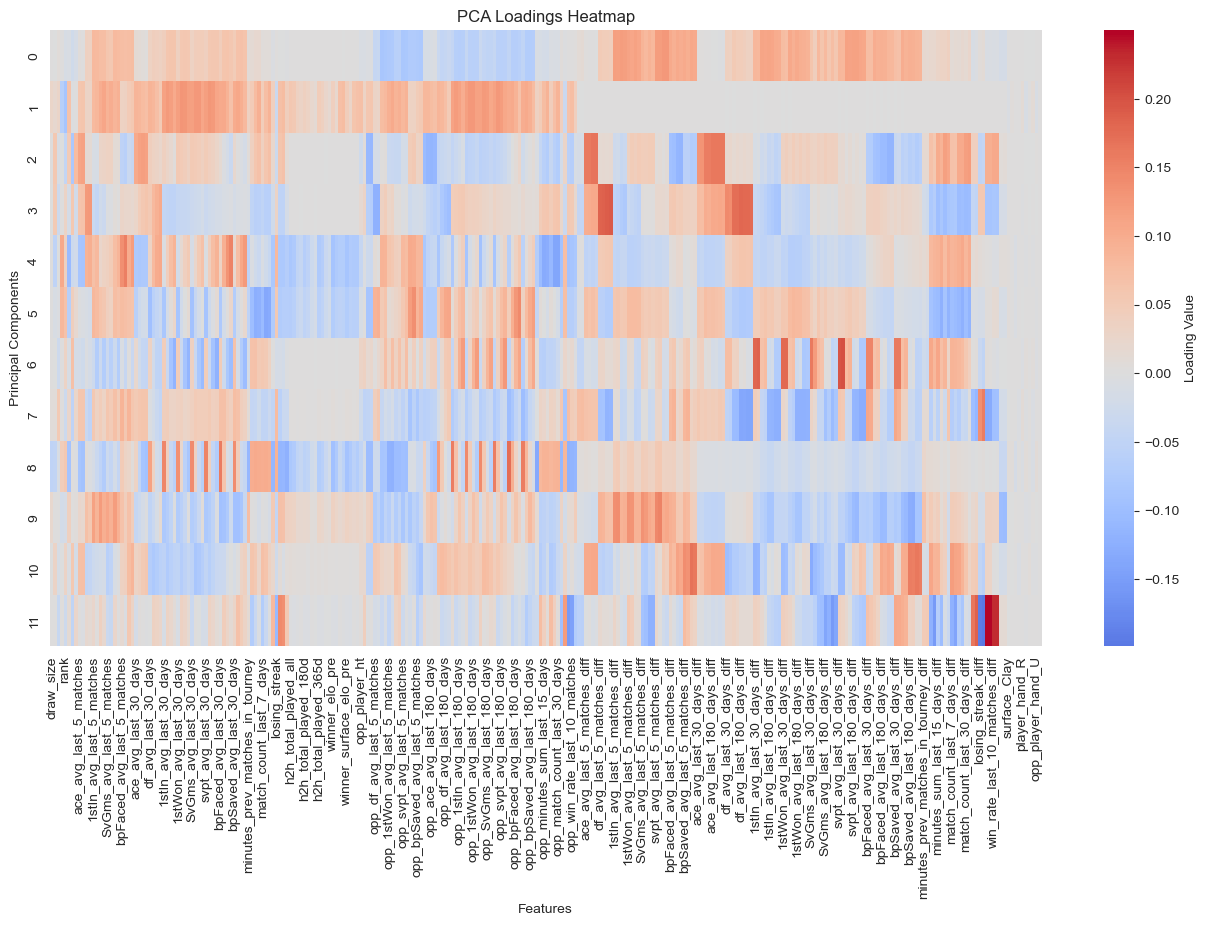

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.heatmap(loadings_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Loading Value'})
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.title('PCA Loadings Heatmap')
plt.show()


In [276]:
top_n = 20

for pc_num in range(loadings_df.shape[0]):
    pc_loadings = loadings_df.iloc[pc_num]
    # 按绝对值排序，取Top 20特征
    top_features = pc_loadings.abs().sort_values(ascending=False).head(top_n).index
    print(f"PC{pc_num+1} Top {top_n} feature loadings:")
    for feat in top_features:
        print(f"  {feat}: {pc_loadings[feat]:.4f}")
    print("-" * 40)


PC1 Top 20 feature loadings:
  svpt_avg_last_10_matches_diff: 0.1261
  svpt_avg_last_10_matches_ratio_log: 0.1243
  1stIn_avg_last_10_matches_diff: 0.1202
  svpt_avg_last_5_matches_diff: 0.1198
  svpt_avg_last_5_matches_ratio_log: 0.1186
  1stIn_avg_last_5_matches_diff: 0.1183
  1stIn_avg_last_10_matches_ratio_log: 0.1174
  1stIn_avg_last_5_matches_ratio_log: 0.1162
  svpt_avg_last_180_days_diff: 0.1149
  svpt_avg_last_180_days_ratio_log: 0.1147
  svpt_avg_last_90_days_diff: 0.1142
  1stWon_avg_last_10_matches_diff: 0.1139
  svpt_avg_last_90_days_ratio_log: 0.1127
  1stWon_avg_last_5_matches_diff: 0.1120
  1stIn_avg_last_90_days_diff: 0.1114
  1stIn_avg_last_180_days_diff: 0.1098
  1stWon_avg_last_10_matches_ratio_log: 0.1085
  1stIn_avg_last_90_days_ratio_log: 0.1082
  1stIn_avg_last_180_days_ratio_log: 0.1079
  1stWon_avg_last_5_matches_ratio_log: 0.1078
----------------------------------------
PC2 Top 20 feature loadings:
  1stWon_avg_last_90_days: 0.1299
  svpt_avg_last_90_days: 0.

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


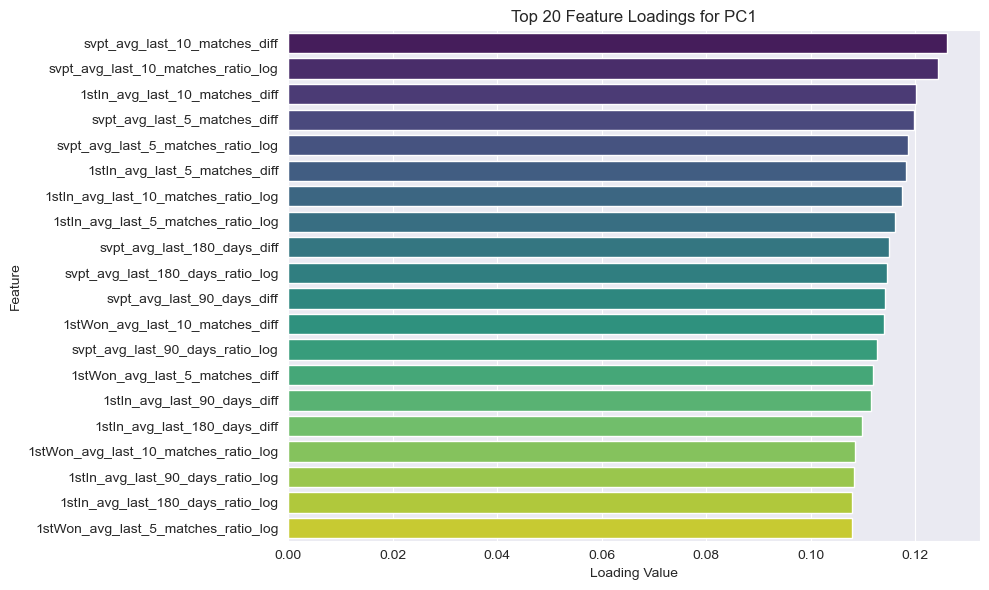

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


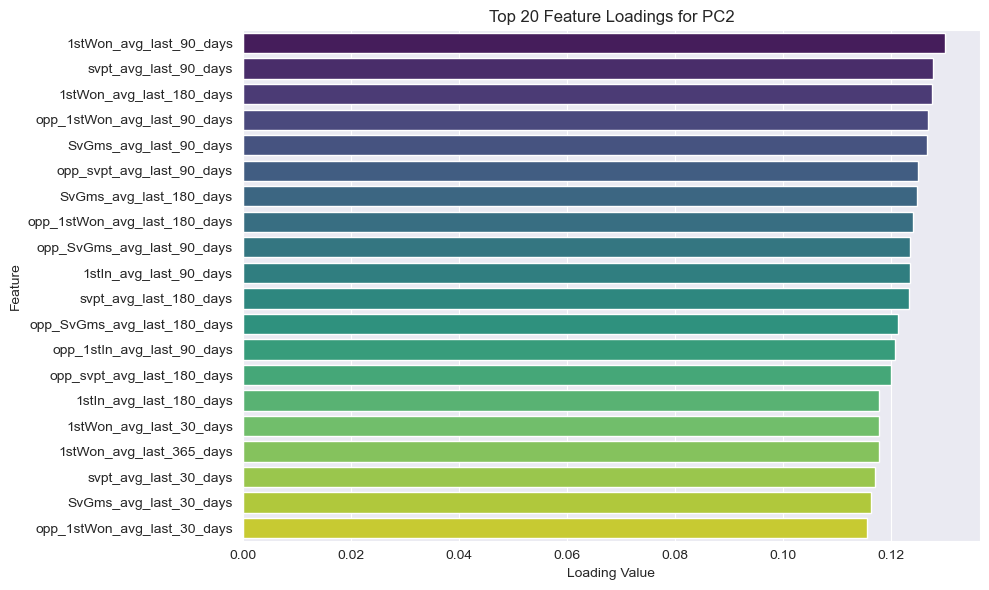

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


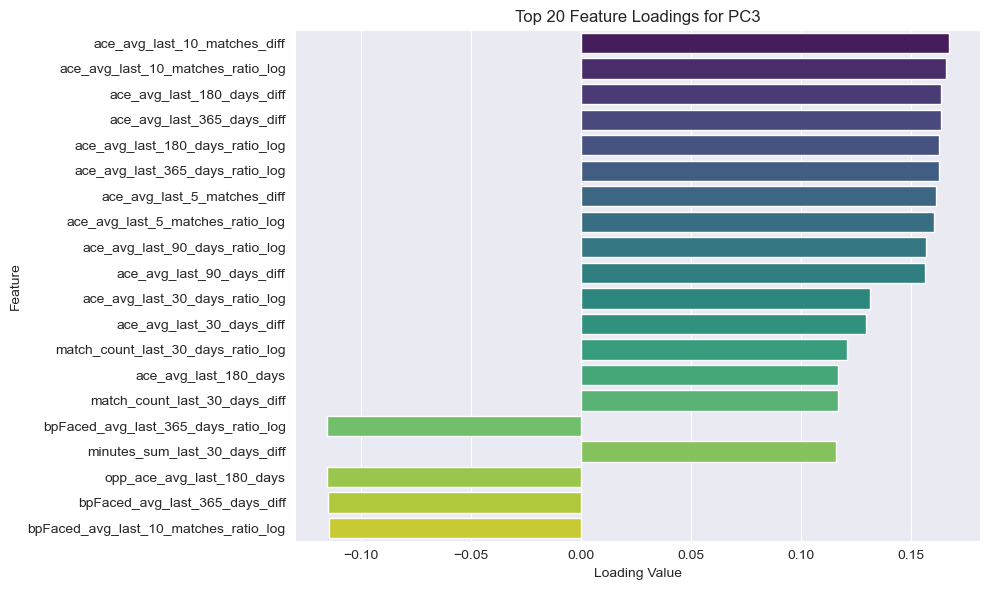

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


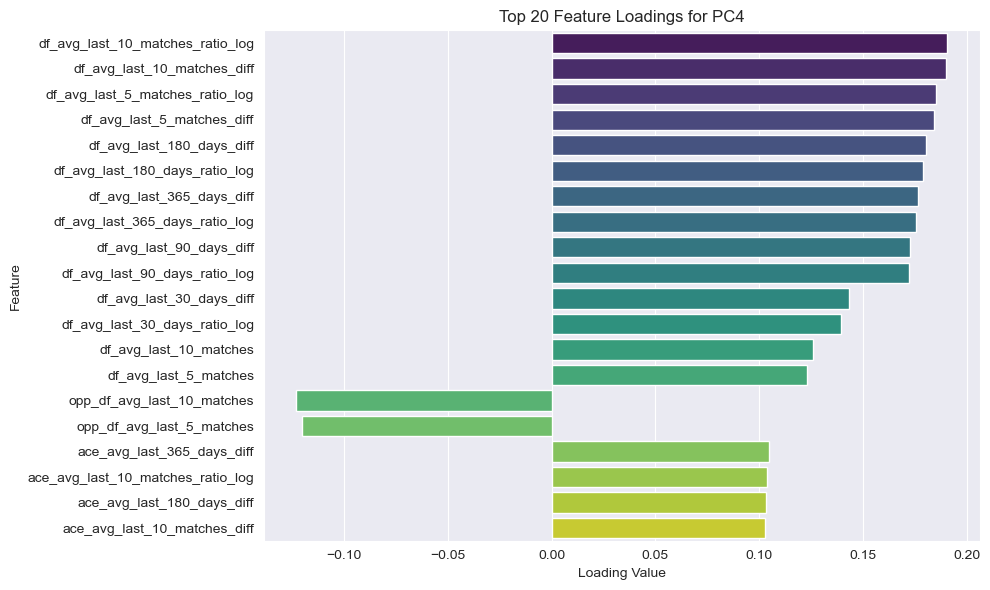

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


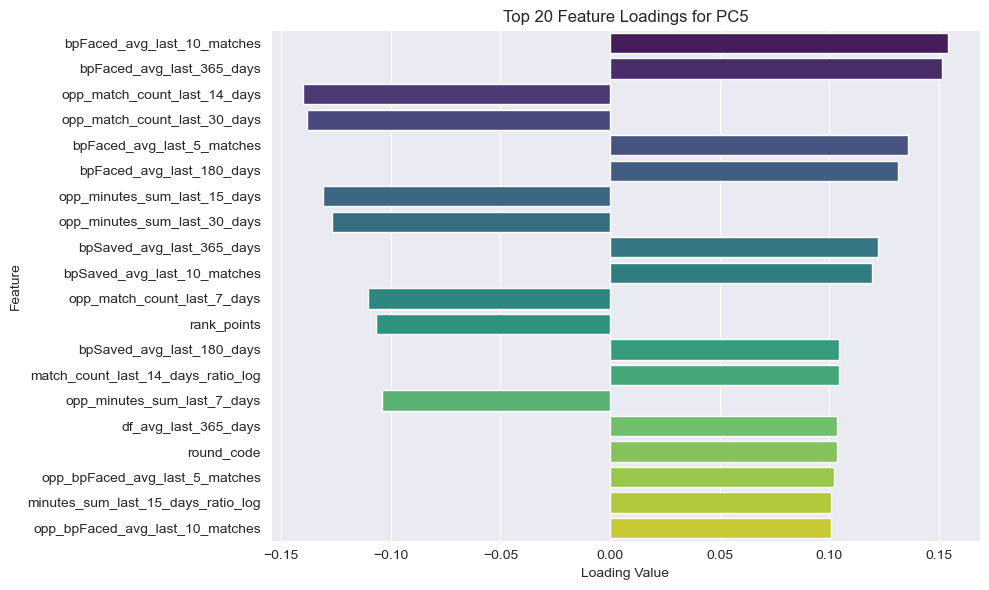

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


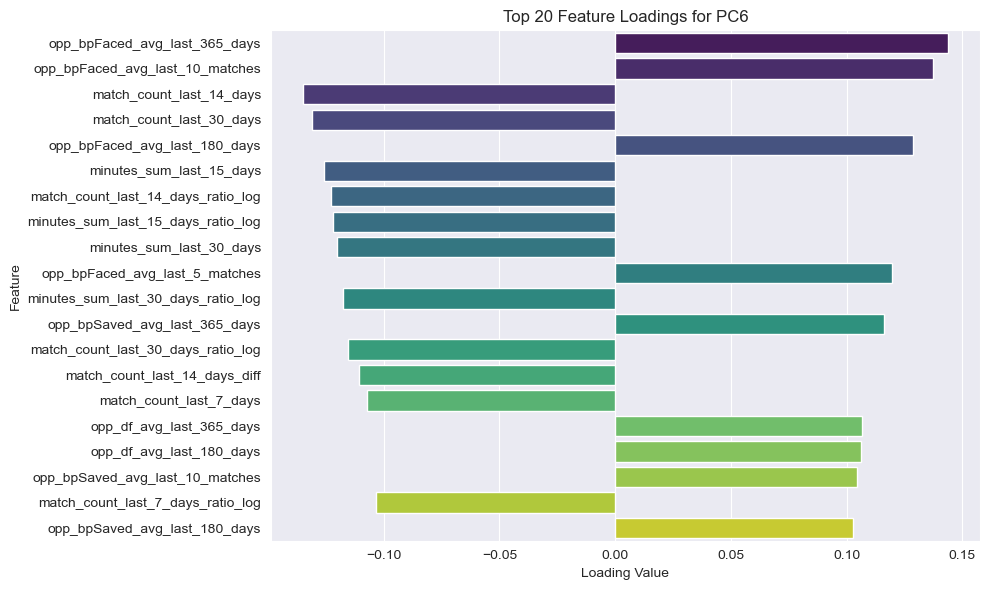

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


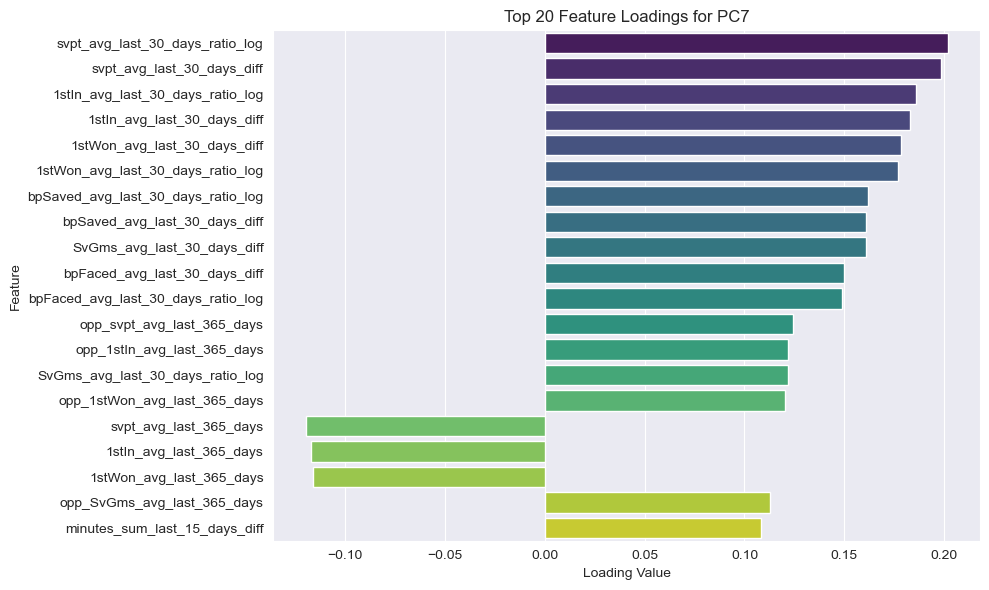

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


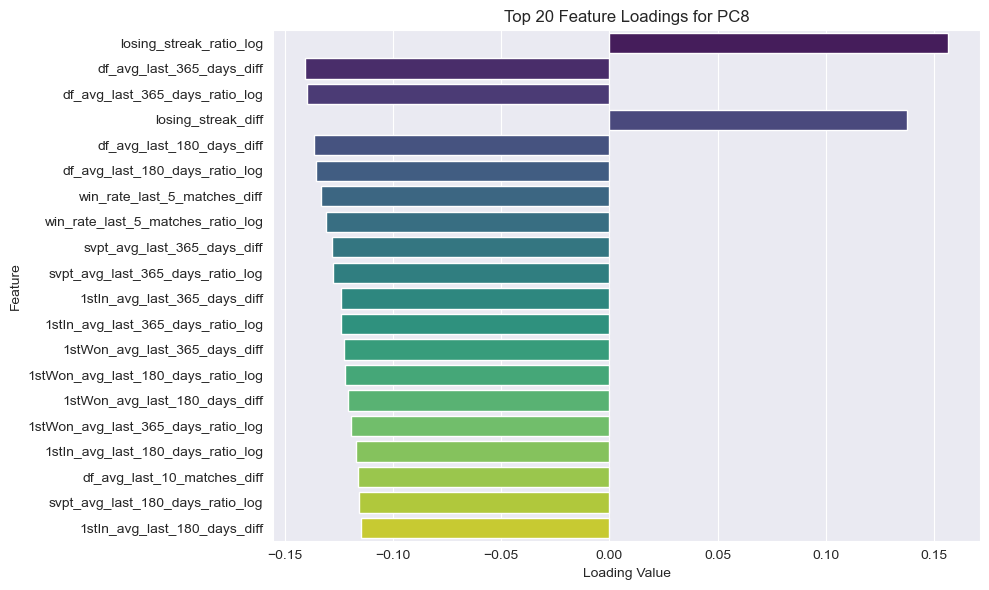

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


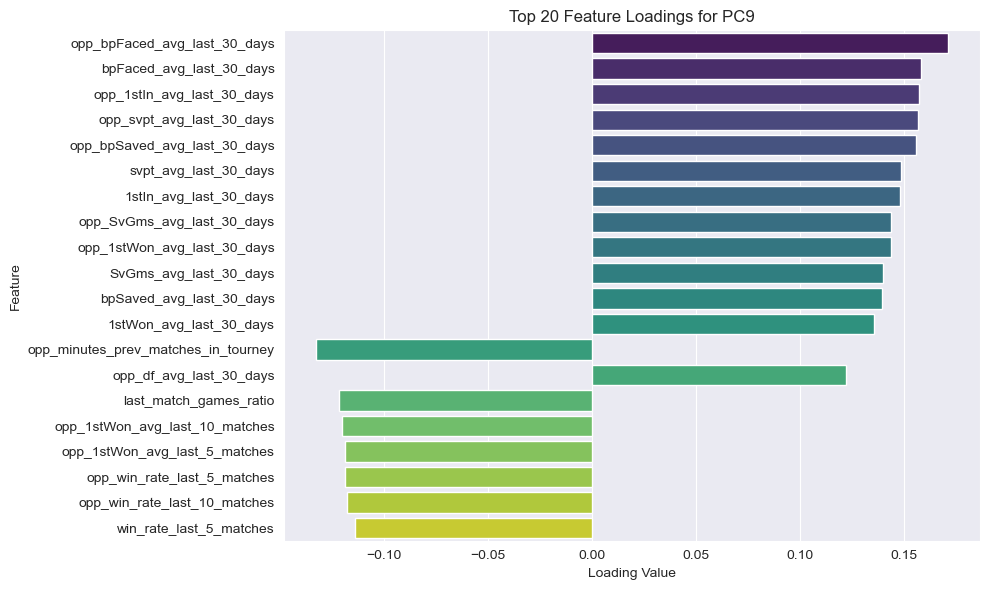

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


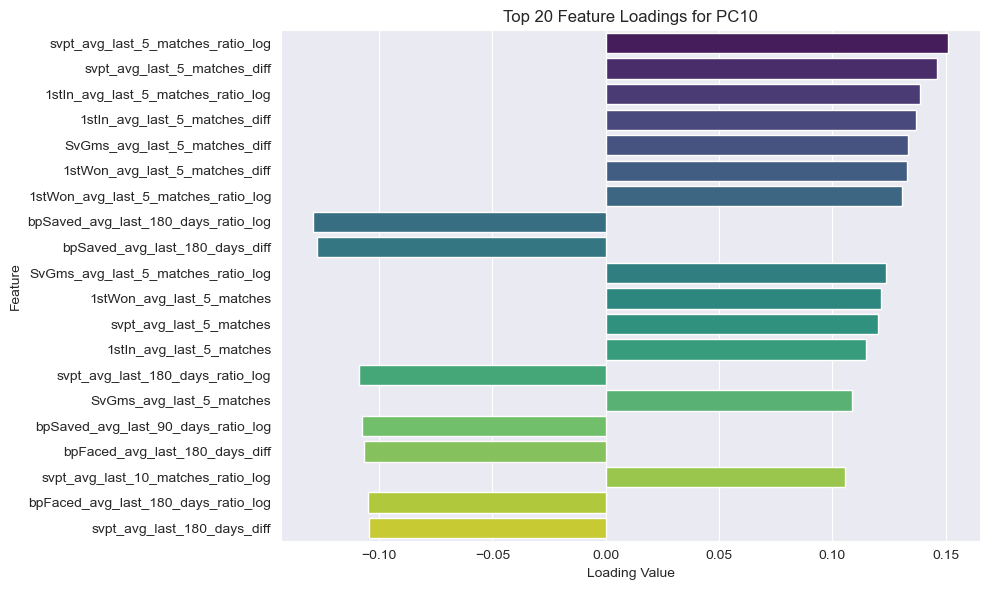

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


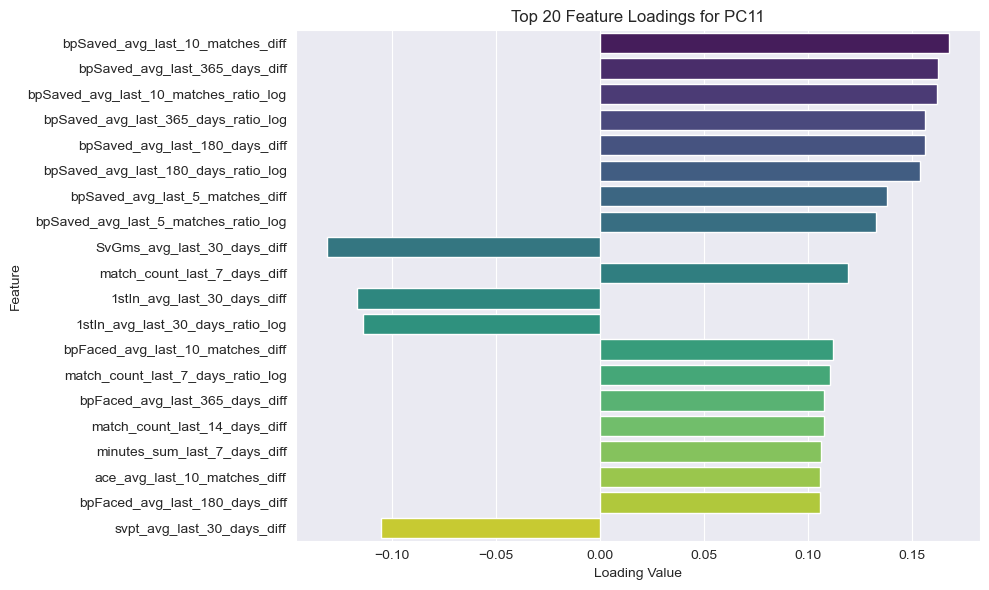

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3756298672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')


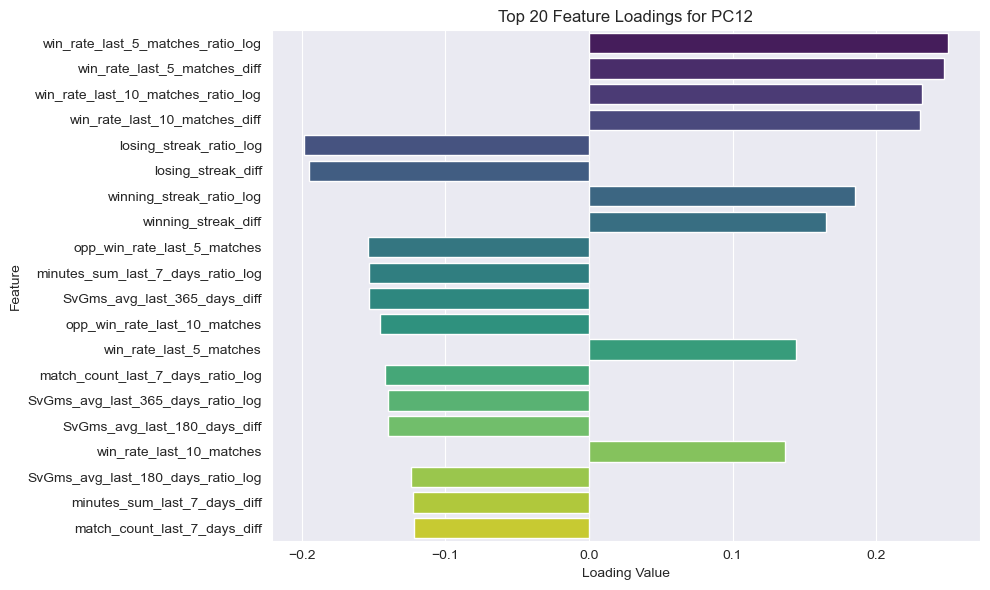

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

top_n = 20
output_dir = 'pca_top20_loadings_plots'
os.makedirs(output_dir, exist_ok=True)

for pc_num in range(loadings_df.shape[0]):
    pc_loadings = loadings_df.iloc[pc_num]
    top_features = pc_loadings.abs().sort_values(ascending=False).head(top_n).index
    plt.figure(figsize=(10, 6))
    sns.barplot(x=pc_loadings[top_features], y=top_features, palette='viridis')
    plt.title(f'Top {top_n} Feature Loadings for PC{pc_num + 1}')
    plt.xlabel('Loading Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/PC{pc_num + 1}_top{top_n}_loadings.png')
    plt.show()


In [272]:
loadings_df.to_excel('pca_loadings_full.xlsx', index=True)
print("PCA loadings saved to 'pca_loadings_full.xlsx'")


PCA loadings saved to 'pca_loadings_full.xlsx'


C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\3898348438.py:22: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance, method='average')


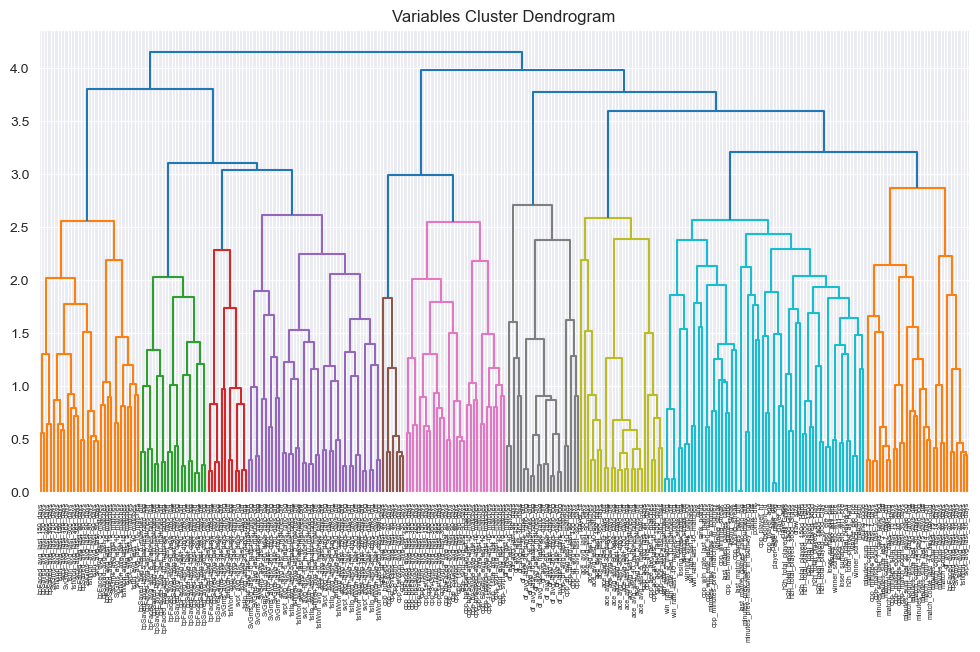

                                      variable  cluster
58                   bpSaved_avg_last_180_days        1
54                   bpFaced_avg_last_180_days        1
55                   bpFaced_avg_last_365_days        2
59                   bpSaved_avg_last_365_days        2
50                      svpt_avg_last_180_days        3
46                     SvGms_avg_last_180_days        3
42                    1stWon_avg_last_180_days        3
38                     1stIn_avg_last_180_days        3
47                     SvGms_avg_last_365_days        4
43                    1stWon_avg_last_365_days        4
39                     1stIn_avg_last_365_days        4
51                      svpt_avg_last_365_days        4
53                    bpFaced_avg_last_90_days        5
57                    bpSaved_avg_last_90_days        5
41                     1stWon_avg_last_90_days        6
37                      1stIn_avg_last_90_days        6
45                      SvGms_avg_last_90_days  

In [266]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的DataFrame叫 X，且都是数值型变量
# 1. 计算相关性矩阵
# 只保留数值列
X_numeric = train_set.select_dtypes(include=[np.number])

# 计算相关性矩阵
corr = X_numeric.corr(method='pearson')


# 2. 相关性矩阵转换为距离矩阵（距离 = 1 - 相关系数）
# 这里因为相关系数范围[-1,1]，用1 - abs(corr)也可
distance = 1 - np.abs(corr)

# 3. 层次聚类
# linkage方法选择ward、average、complete均可，试试看average
Z = linkage(distance, method='average')

# 4. 画树状图
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=corr.columns, leaf_rotation=90)
plt.title('Variables Cluster Dendrogram')
plt.show()

# 5. 根据树状图，选择合适的阈值cut-off来划分聚类，比如距离阈值0.5
clusters = fcluster(Z, t=1, criterion='distance')

# 查看每个变量所属的簇
cluster_df = pd.DataFrame({'variable': corr.columns, 'cluster': clusters})
print(cluster_df.sort_values('cluster'))


In [247]:
import pandas as pd
import numpy as np

# 示例：clusters是一个array，长度 = X_numeric列数，值是簇号
# clusters = fcluster(Z, t=某个值, criterion='distance')

# 构造一个DataFrame，列名+簇标签
cluster_df = pd.DataFrame({'variable': X_numeric.columns, 'cluster': clusters})
Y = train_set['Y']  # 确认你的目标列名字是'Y'

selected_vars = []

for cluster_id in cluster_df['cluster'].unique():
    vars_in_cluster = cluster_df.loc[cluster_df['cluster'] == cluster_id, 'variable'].tolist()
    # 计算这些变量与Y的相关性
    corr_with_y = X_numeric[vars_in_cluster].apply(lambda x: abs(x.corr(Y)))
    # 选出相关性最大的变量
    best_var = corr_with_y.idxmax()
    selected_vars.append(best_var)

all_vars = X_numeric.columns.tolist()
# 要排除的变量 = all_vars - selected_vars
drop_var = [var for var in all_vars if var not in selected_vars]


print(f"每个簇中与Y相关性最高的变量有 {len(selected_vars)} 个")
print("选出的变量列表：", selected_vars)
print(f"排除的变量共有 {len(drop_var)} 个")
print("排除的变量列表：", drop_var)

每个簇中与Y相关性最高的变量有 123 个
选出的变量列表： ['draw_size', 'match_num', 'year', 'player_id', 'player_ht', 'opponent_id', 'round_code', 'rank', 'rank_points', 'rank_diff', 'points_diff', 'ace_avg_last_180_days', 'df_avg_last_10_matches', 'svpt_avg_last_5_matches', 'svpt_avg_last_10_matches', '1stWon_avg_last_10_matches', 'SvGms_avg_last_10_matches', 'bpFaced_avg_last_5_matches', 'bpFaced_avg_last_10_matches', 'ace_avg_last_30_days', 'df_avg_last_30_days', 'df_avg_last_90_days', 'df_avg_last_180_days', '1stWon_avg_last_30_days', '1stWon_avg_last_90_days', '1stWon_avg_last_180_days', '1stWon_avg_last_365_days', 'bpSaved_avg_last_30_days', 'bpSaved_avg_last_90_days', 'bpSaved_avg_last_180_days', 'bpSaved_avg_last_365_days', 'minutes_prev_matches_in_tourney', 'match_count_last_7_days', 'match_count_last_14_days', 'match_count_last_30_days', 'winning_streak', 'losing_streak', 'win_rate_last_10_matches', 'last_match_games_ratio', 'h2h_total_played_all_Hard', 'h2h_total_played_all_Clay', 'h2h_total_played_a

In [ ]:
# X_numeric = train_set.select_dtypes(include=[np.number])
# corr = X_numeric.corr().abs()  # 取绝对值方便判断相关强弱
# def select_low_correlated_features(df, threshold=0.58):
#     corr = df.corr().abs()
#     upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # 取上三角矩阵
#     drop_cols = [column for column in upper.columns if any(upper[column] > threshold)]
#     selected_features = df.columns.difference(drop_cols)
#     return selected_features.tolist(), drop_cols
#
# selected_vars, drop_vars = select_low_correlated_features(X_numeric, threshold=0.85)
# print(f"保留变量数：{len(selected_vars)}")
# print(f"需要删除的变量数：{len(drop_vars)}")
# print(f"保留变量：{selected_vars}")
# print(f"删除变量：{drop_vars}")


In [254]:
# 定义需要去掉的列
id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name', 'tourney_date', 'match_num', 'year', 'player_ioc','player_seed', 'opponent_seed']
# 假设 'Y' 是目标变量，去除 'Y' 以及非特征列,'player_entry'

X = train_set.drop(columns=id_columns + drop_var + ['Y'])
# X = train_set[selected_vars].copy()
y = train_set['Y']


# 区分类别型和数值型
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

X[categorical_features] = X[categorical_features].fillna('missing')
for col in categorical_features:
    X[col] = X[col].astype(str)

# 定义预处理器
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 定义包含预处理和模型的pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('select_kbest', SelectKBest(score_func=f_classif, k=13)),  # 只选13个特征
    ('logreg', LogisticRegressionCV(
        cv=3,
        penalty='l2',
        solver='saga',
        max_iter=1000,
        n_jobs=-1,
        tol=1e-3,
        scoring='roc_auc',
        Cs=5
    ))
])


# 训练
pipe.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['draw_size', 'player_ht',
                                                   'round_code', 'rank',
                                                   'rank_points', 'rank_diff',
                                                   'points_diff',
                                                   'df_avg_last_10_matches',
                                                   '1stWon_avg_last_10_matches',
                                                   'SvGms_avg_last_10_matches',
                                                   'svpt_avg_last_5_matches',
                                                   'svpt_avg_last_10_matches',
                                                   'bpFaced_avg_last_5_matches',
                                                   'bpFaced_avg_...
                                                   'bpSaved_avg_last_365_days',
                                                   'minutes_prev_matches_in_tourney',
                                                   'match_count_last_7_days',
                                                   'match_count_last_14_days', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface', 'player_hand',
                                                   'opp_player_hand'])])),
                ('select_kbest', SelectKBest(k=13)),
                ('logreg',
                 LogisticRegressionCV(Cs=5, cv=3, max_iter=1000, n_jobs=-1,
                                      scoring='roc_auc', solver='saga',
                                      tol=0.001))])

In [263]:
# 1. 获取预处理后所有特征名
preprocessor = pipe.named_steps['preprocessor']

num_features = numeric_features
cat_features = categorical_features

ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_features)

all_features = list(num_features) + list(ohe_feature_names)

print(f"预处理后特征总数: {len(all_features)}")

# 2. 获取 SelectKBest 的支持布尔数组
select_kbest = pipe.named_steps['select_kbest']
selected_mask = select_kbest.get_support()

print(f"SelectKBest选择了 {sum(selected_mask)} 个特征")

# 3. 选中列对应的名字
selected_features = [f for f, selected in zip(all_features, selected_mask) if selected]

# 4. 模型系数
coef = pipe.named_steps['logreg'].coef_.flatten()

print(f"模型系数个数: {len(coef)}")

# 5. 确认系数数量和特征数量一致
assert len(coef) == len(selected_features)

# 6. 构造 DataFrame
import pandas as pd
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'coefficient': coef,
    'abs_coef': abs(coef)
}).sort_values(by='abs_coef', ascending=False)

print(feature_importance.head(20))


预处理后特征总数: 282
SelectKBest选择了 13 个特征
模型系数个数: 13
                                      feature  coefficient  abs_coef
2                                 points_diff     0.550352  0.550352
5        minutes_prev_matches_in_tourney_diff     0.482809  0.482809
6   minutes_prev_matches_in_tourney_ratio_log     0.430763  0.430763
1                                   rank_diff    -0.292902  0.292902
10         match_count_last_30_days_ratio_log     0.150152  0.150152
4         bpFaced_avg_last_365_days_ratio_log    -0.103861  0.103861
11              win_rate_last_10_matches_diff     0.101736  0.101736
12         win_rate_last_10_matches_ratio_log     0.020211  0.020211
8          minutes_sum_last_30_days_ratio_log     0.014215  0.014215
0                                 rank_points     0.010481  0.010481
3              bpFaced_avg_last_365_days_diff    -0.000038  0.000038
7               minutes_sum_last_30_days_diff     0.000000  0.000000
9               match_count_last_30_days_diff     0.0000

C:\Users\ZhouKan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhouKan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhouKan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhouKan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhouKan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) Arial.
  fig.canvas.prin

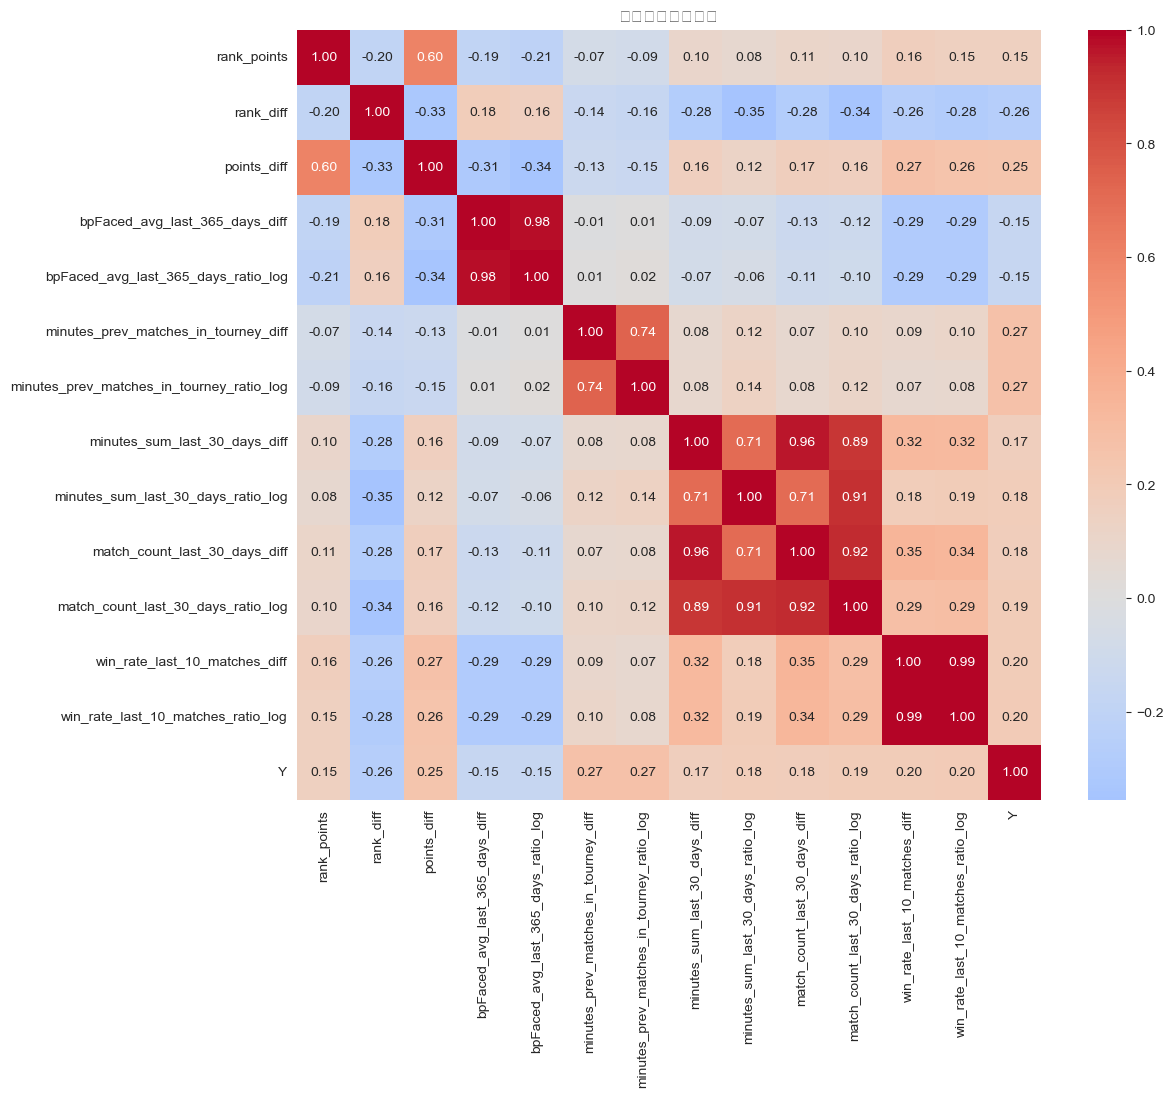

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns
# 假设你有训练数据train_set，Y是目标变量
# 13个变量名字列表，注意要和你的feature_importance中的feature对应
# selected_features = [
#     'rank_diff',
#     'points_diff',
#     'minutes_prev_matches_in_tourney',
#     'rank',
#     'match_count_last_30_days',
#     'ace_avg_last_180_days',
#     'win_rate_last_10_matches',
#     '1stWon_avg_last_180_days',
#     '1stWon_avg_last_365_days',
#     'rank_points',
#     'ace_avg_last_90_days',
#     '1stWon_avg_last_90_days',
#     'SvGms_avg_last_90_days'
# ]



# 取这13个变量 + 目标Y
df_corr = train_set[selected_features + ['Y']].copy()

# 计算相关系数矩阵
corr_matrix = df_corr.corr(method='pearson')

# 画热力图
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('相关性矩阵热力图')
plt.show()


In [256]:
# 预处理器
preprocessor = pipe.named_steps['preprocessor']

# ========= 训练集预测 =========
y_train_pred = pipe.predict(X)
y_train_proba = pipe.predict_proba(X)[:, 1]

# ========= 训练集指标评估 =========
accuracy_train = accuracy_score(y, y_train_pred)
precision_train = precision_score(y, y_train_pred)
recall_train = recall_score(y, y_train_pred)
f1_train = f1_score(y, y_train_pred)
roc_auc_train = roc_auc_score(y, y_train_proba)

print("====== Training Set Evaluation ======")
print(f"Accuracy:    {accuracy_train:.4f}")
print(f"Precision:   {precision_train:.4f}")
print(f"Recall:      {recall_train:.4f}")
print(f"F1 Score:    {f1_train:.4f}")
print(f"ROC AUC:     {roc_auc_train:.4f}")

print("\nClassification Report:")
print(classification_report(y, y_train_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_train_pred))


====== Training Set Evaluation ======
Accuracy:    0.6832
Precision:   0.6851
Recall:      0.6747
F1 Score:    0.6799
ROC AUC:     0.7573

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69     15525
           1       0.69      0.67      0.68     15441

    accuracy                           0.68     30966
   macro avg       0.68      0.68      0.68     30966
weighted avg       0.68      0.68      0.68     30966


Confusion Matrix:
[[10737  4788]
 [ 5023 10418]]


In [257]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1. 提取特征和标签（同训练时一样剔除id和目标列）
X_test = test_set.drop(columns=id_columns + ['Y'])
y_test = test_set['Y']

# 2. 类别变量填充与类型转换（保持和训练时一致）
X_test[categorical_features] = X_test[categorical_features].fillna('missing').astype(str)

# 3. 用训练好的pipe直接预测
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# 4. 评估指标计算
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC AUC:     {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy:    0.6868
Precision:   0.6941
Recall:      0.6749
F1 Score:    0.6844
ROC AUC:     0.7601

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      6594
           1       0.69      0.67      0.68      6678

    accuracy                           0.69     13272
   macro avg       0.69      0.69      0.69     13272
weighted avg       0.69      0.69      0.69     13272


Confusion Matrix:
[[4608 1986]
 [2171 4507]]


In [258]:
# 1. 提取特征和标签（剔除id和目标列）
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']

# 2. 类别变量填充与类型转换（保持和训练时一致）
X_val[categorical_features] = X_val[categorical_features].fillna('missing').astype(str)

# 3. 用训练好的pipe直接预测
y_val_pred = pipe.predict(X_val)
y_val_proba = pipe.predict_proba(X_val)[:, 1]

# 4. 评估指标计算
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
roc_auc_val = roc_auc_score(y_val, y_val_proba)

print(f"Validation set Accuracy:    {accuracy_val:.4f}")
print(f"Validation set Precision:   {precision_val:.4f}")
print(f"Validation set Recall:      {recall_val:.4f}")
print(f"Validation set F1 Score:    {f1_val:.4f}")
print(f"Validation set ROC AUC:     {roc_auc_val:.4f}")

print("\nValidation set Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nValidation set Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


Validation set Accuracy:    0.6089
Validation set Precision:   0.6113
Validation set Recall:      0.5983
Validation set F1 Score:    0.6047
Validation set ROC AUC:     0.6490

Validation set Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.62      0.61      4030
           1       0.61      0.60      0.60      4030

    accuracy                           0.61      8060
   macro avg       0.61      0.61      0.61      8060
weighted avg       0.61      0.61      0.61      8060


Validation set Confusion Matrix:
[[2497 1533]
 [1619 2411]]


In [ ]:
# 随机森林

In [324]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name', 'tourney_date', 'match_num', 'year', 'player_ioc','player_seed', 'opponent_seed']
# 假设 'Y' 是目标变量，去除 'Y' 以及非特征列,'player_entry'

X = train_set.drop(columns=id_columns + ['Y'])

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

# 填充缺失值
X[categorical_features] = X[categorical_features].fillna('missing')
X[numeric_features] = X[numeric_features].fillna(0)

for col in categorical_features:
    X[col] = X[col].astype(str)

# 预处理器，不对数值做标准化，随机森林对尺度不敏感，直接用数值即可
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
# 预处理：类别型 -> OneHot, 数值型 -> 保持不变


# 随机森林分类器
rf_clf = RandomForestClassifier(
    # n_estimators = 350,
    max_depth=6,  # 限制树深度防止过拟合
    # min_samples_split = 35,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', rf_clf)
])

# 训练
pipe.fit(X, y)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['draw_size', 'player_ht',
                                                   'player_age', 'round_code',
                                                   'rank', 'rank_points',
                                                   'rank_diff', 'points_diff',
                                                   'ace_avg_last_5_matches',
                                                   'ace_avg_last_10_matches',
                                                   'df_avg_last_5_matches',
                                                   'df_avg_last_10_matches',
                                                   '1stIn_avg_last_5_matches',
                                                   '1stIn_avg_last_10_matches',
                                                   '1stWon_avg_...
                                                   'bpSaved_avg_last_10_matches',
                                                   'ace_avg_last_30_days',
                                                   'ace_avg_last_90_days',
                                                   'ace_avg_last_180_days',
                                                   'ace_avg_last_365_days',
                                                   'df_avg_last_30_days',
                                                   'df_avg_last_90_days', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface', 'player_hand',
                                                   'opp_player_hand'])])),
                ('rf',
                 RandomForestClassifier(max_depth=6, min_samples_leaf=15,
                                        n_jobs=-1, random_state=42))])

In [38]:
import joblib

# 假设 best_model 是你训练好的 Pipeline 模型
joblib.dump(pipe, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [22]:
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np
#
# # 参数搜索空间
# param_dist = {
#     'rf__n_estimators': np.arange(100, 400, 50),     # 100~500步长50
#     'rf__max_depth': [6, 8, 10, 12],
#     'rf__min_samples_split': np.arange(20, 41, 2 ),       # 2~10
#     'rf__min_samples_leaf': np.arange(15, 21),        # 1~20
#     'rf__max_features': ['sqrt', 'log2', None]
# }
#
# # 随机搜索
# random_search = RandomizedSearchCV(
#     pipe,
#     param_distributions=param_dist,
#     n_iter=20,             # 抽取30组参数组合
#     cv=3,
#     scoring='accuracy',    # 或 'roc_auc'
#     n_jobs=-1,
#     verbose=2,
#     random_state=42
# )
#
# # 拟合
# random_search.fit(X, y)
#
# print("最佳参数:", random_search.best_params_)
# print("最佳CV得分:", random_search.best_score_)
#
# # 最优模型
# best_model = random_search.best_estimator_
#
# # 如果有测试集，可以评估
# # y_pred = best_model.predict(X_test)
# # print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
最佳参数: {'rf__n_estimators': 300, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 16, 'rf__max_features': None, 'rf__max_depth': 12}
最佳CV得分: 0.8323322353549054


In [130]:
# 查看整个Pipeline的参数字典
print(best_model.get_params())

# 单独取随机森林模型对象
rf_model = best_model.named_steps['rf']

# 查看随机森林模型的所有参数
print(rf_model.get_params())

# 如果只想看某几个关键参数，比如树的数量和深度
print("n_estimators:", rf_model.n_estimators)
print("max_depth:", rf_model.max_depth)
print("min_samples_leaf:", rf_model.min_samples_leaf)


{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['draw_size', 'player_ht', 'player_age',
                                  'round_code', 'rank', 'rank_points',
                                  'rank_diff', 'points_diff',
                                  'ace_avg_last_5_matches',
                                  'ace_avg_last_10_matches',
                                  'df_avg_last_5_matches',
                                  'df_avg_last_10_matches',
                                  '1stIn_avg_last_5_matches',
                                  '1stIn_avg_last_10_matches',
                                  '1stWon_avg_last_5_matches',
                                  '1stWon_avg_last...
                                  'bpFaced_avg_last_5_matches',
                                  'bpFaced_avg_last_10_matches',
                                  'bpSaved_avg_last_5_matches',
                   

In [325]:
# 训练集预测
# y_train_pred = best_model.predict(X)
# y_train_proba = best_model.predict_proba(X)[:, 1]
# pipe
y_train_pred = pipe.predict(X)
y_train_proba = pipe.predict_proba(X)[:, 1]

# 打印训练集评估指标
print("Training set Accuracy:", accuracy_score(y, y_train_pred))
print("Training set ROC AUC:", roc_auc_score(y, y_train_proba))
print("Training set classification report:")
print(classification_report(y, y_train_pred))

Training set Accuracy: 0.7350642640315185
Training set ROC AUC: 0.8405672498537626
Training set classification report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74     15525
           1       0.73      0.73      0.73     15441

    accuracy                           0.74     30966
   macro avg       0.74      0.74      0.74     30966
weighted avg       0.74      0.74      0.74     30966



In [326]:
# 预测和评估（假设你有test_set）
X_test = test_set.drop(columns=id_columns + ['Y'])
y_test = test_set['Y']

X_test[categorical_features] = X_test[categorical_features].fillna('missing')
X_test[numeric_features] = X_test[numeric_features].fillna(0)

for col in categorical_features:
    X_test[col] = X_test[col].astype(str)

# y_pred = best_model.predict(X_test)
# y_pred_proba = best_model.predict_proba(X_test)[:,1]
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:,1]

print("test set Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

test set Accuracy: 0.7179776974080772
ROC AUC: 0.82083117935179
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      6594
           1       0.72      0.71      0.72      6678

    accuracy                           0.72     13272
   macro avg       0.72      0.72      0.72     13272
weighted avg       0.72      0.72      0.72     13272



In [327]:
# 预测和评估（假设你有test_set）
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']

X_val[categorical_features] = X_val[categorical_features].fillna('missing')
X_val[numeric_features] = X_val[numeric_features].fillna(0)

for col in categorical_features:
    X_val[col] = X_val[col].astype(str)

# y_pred = best_model.predict(X_val)
# y_pred_proba = best_model.predict_proba(X_val)[:,1]
y_pred = pipe.predict(X_val)
y_pred_proba = pipe.predict_proba(X_val)[:,1]


print("validation_set Accuracy:", accuracy_score(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_pred_proba))
print(classification_report(y_val, y_pred))

validation_set Accuracy: 0.6859801488833747
ROC AUC: 0.7733682246673522
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      4030
           1       0.68      0.70      0.69      4030

    accuracy                           0.69      8060
   macro avg       0.69      0.69      0.69      8060
weighted avg       0.69      0.69      0.69      8060



In [330]:
import numpy as np

# 数值列直接对应
num_features = numeric_features

# 类别列经过OneHotEncoder后扩展的列名
cat_transformer = pipe.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = cat_transformer.get_feature_names_out(categorical_features)

# 合并所有预处理后列名
all_feature_names = np.concatenate([num_features, ohe_feature_names])
importances = pipe.named_steps['rf'].feature_importances_

# 组成DataFrame
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

# 按重要性降序排序
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print(feat_imp_df.head(20))

                                      feature  importance
0                                 points_diff    0.094160
1   minutes_prev_matches_in_tourney_ratio_log    0.090564
2                                   rank_diff    0.077906
3        minutes_prev_matches_in_tourney_diff    0.060293
4                              winner_elo_pre    0.034376
5                           loser_elo_wt1_pre    0.033263
6                          winner_elo_wt1_pre    0.026904
7                                 rank_points    0.026877
8          win_rate_last_10_matches_ratio_log    0.023832
9                      winner_surface_elo_pre    0.023177
10                              loser_elo_pre    0.022300
11                  loser_surface_elo_wt1_pre    0.021039
12                                       rank    0.020249
13         match_count_last_30_days_ratio_log    0.017616
14                 winner_surface_elo_wt1_pre    0.016545
15              win_rate_last_10_matches_diff    0.016200
16            

In [ ]:
# LightGBM

In [285]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 去掉非特征列
id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name',
              'tourney_date', 'match_num', 'year', 'player_ioc', 'player_seed', 'opponent_seed']

X = train_set.drop(columns=id_columns + ['Y'])
y = train_set['Y']

# 数值和类别列
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

# 缺失值处理
X[categorical_features] = X[categorical_features].fillna('missing')
X[numeric_features] = X[numeric_features].fillna(0)

# 转字符串
for col in categorical_features:
    X[col] = X[col].astype(str)

# 预处理（LightGBM 可以直接处理类别编码，但如果你想和随机森林保持一致，可以 OneHot）
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# LightGBM 分类器
lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,   # 限制深度
    num_leaves=31,  # 默认叶子数
    min_data_in_leaf = 20,
    random_state=42,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lgbm', lgbm_clf)
])

# 训练
pipe.fit(X, y)




[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 15441, number of negative: 15525
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57167
[LightGBM] [Info] Number of data points in the train set: 30966, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498644 -> initscore=-0.005425
[LightGBM] [Info] Start training from score -0.005425
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['draw_size', 'player_ht',
                                                   'player_age', 'round_code',
                                                   'rank', 'rank_points',
                                                   'rank_diff', 'points_diff',
                                                   'ace_avg_last_5_matches',
                                                   'ace_avg_last_10_matches',
                                                   'df_avg_last_5_matches',
                                                   'df_avg_last_10_matches',
                                                   '1stIn_avg_last_5_matches',
                                                   '1stIn_avg_last_10_matches',
                                                   '1stWon_avg_...
                                                   'ace_avg_last_90_days',
                                                   'ace_avg_last_180_days',
                                                   'ace_avg_last_365_days',
                                                   'df_avg_last_30_days',
                                                   'df_avg_last_90_days', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface', 'player_hand',
                                                   'opp_player_hand'])])),
                ('lgbm',
                 LGBMClassifier(learning_rate=0.05, max_depth=7,
                                min_data_in_leaf=20, n_estimators=500,
                                n_jobs=-1, random_state=42, reg_alpha=0.1,
                                reg_lambda=0.1))])

In [286]:
# 训练集预测
y_train_pred = pipe.predict(X)
y_train_proba = pipe.predict_proba(X)[:, 1]

# 对 validation_set 做同样预处理和预测
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']

# 注意：用 pipe 里的预处理器变换 X_val
y_val_pred = pipe.predict(X_val)
y_val_proba = pipe.predict_proba(X_val)[:, 1]

# 对 test_set 做同样处理
X_test = test_set.drop(columns=id_columns + ['Y'])
y_test = test_set['Y']

y_test_pred = pipe.predict(X_test)
y_test_proba = pipe.predict_proba(X_test)[:, 1]

# 评估示例
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 评估
print("Training Accuracy:", accuracy_score(y, y_pred))
print("Training ROC AUC:", roc_auc_score(y, y_pred_proba))
print(classification_report(y, y_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred))


print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))
print(classification_report(y_val, y_val_pred))



C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [30966, 8060]

In [186]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 假设 id_columns, train_set, validation_set 已经定义好

# 特征准备
id_columns = ['player_id', 'player_name', 'opponent_id', 'tourney_id', 'tourney_name',
              'tourney_date', 'match_num', 'year', 'player_ioc', 'player_seed', 'opponent_seed']

X_train = train_set.drop(columns=id_columns + ['Y'])
y_train = train_set['Y']
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']

categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

# 缺失值填充
for df in [X_train, X_val]:
    df[categorical_features] = df[categorical_features].fillna('missing')
    df[numeric_features] = df[numeric_features].fillna(0)
    for col in categorical_features:
        df[col] = df[col].astype(str)  # OneHotEncoder 要求字符串类型

# 构造预处理Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipe = Pipeline([
    ('preprocessor', preprocessor)
])

# 先拟合预处理器
pipe.fit(X_train)

X_train_processed = pipe.transform(X_train)
X_val_processed = pipe.transform(X_val)

# LightGBM 模型配置
lgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=31,
    min_data_in_leaf=30,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1
)

# 训练并使用 early stopping
lgbm_clf.fit(
    X_train_processed, y_train,
    eval_set=[(X_val_processed, y_val)],
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)   # 每50轮输出一次日志
    ]
)

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Number of positive: 15441, number of negative: 15525
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57167
[LightGBM] [Info] Number of data points in the train set: 30966, number of used features: 281
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498644 -> initscore=-0.005425
[LightGBM] [Info] Start training from score -0.005425
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.838857	valid_0's binary_logloss: 0.588661
[100]	valid_0

LGBMClassifier(learning_rate=0.01, max_depth=7, min_data_in_leaf=30,
               n_estimators=2000, n_jobs=-1, random_state=42, reg_alpha=0.5,
               reg_lambda=0.5)

In [305]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# 特征准备，和你之前一样
# ...

# 构造预处理器并拟合（注意只拟合，不放入模型管道fit）
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor.fit(X_train)

# 预处理转换数据
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# LightGBM 配置和训练（支持 early stopping）
lgbm_clf = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.005,
    max_depth= 5,
    num_leaves=15,
    min_data_in_leaf=50,
    reg_alpha=2,
    reg_lambda=2,
    random_state=42,
    bagging_fraction=0.8,
    feature_fraction=0.8,
    bagging_freq=1,
    n_jobs=-1
)

lgbm_clf.fit(
    X_train_processed, y_train,
    eval_set=[(X_val_processed, y_val)],
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=50)
    ]
)

# 训练完成后，合成 Pipeline，方便保存和后续直接预测
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lgbm', lgbm_clf)
])

# 保存 Pipeline 模型
joblib.dump(full_pipe, 'lgbm_pipeline_model.pkl')


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Number of positive: 15441, number of neg

['lgbm_pipeline_model.pkl']

In [306]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 训练集预测（先转换，再预测）
X_train_processed = pipe.named_steps['preprocessor'].transform(X)
y_train_pred = lgbm_clf.predict(X_train_processed)
y_train_proba = lgbm_clf.predict_proba(X_train_processed)[:, 1]

# validation_set 预处理与预测
X_val = validation_set.drop(columns=id_columns + ['Y'])
y_val = validation_set['Y']
X_val_processed = pipe.named_steps['preprocessor'].transform(X_val)
y_val_pred = lgbm_clf.predict(X_val_processed)
y_val_proba = lgbm_clf.predict_proba(X_val_processed)[:, 1]

# test_set 预处理与预测
X_test = test_set.drop(columns=id_columns + ['Y'])
y_test = test_set['Y']
X_test_processed = pipe.named_steps['preprocessor'].transform(X_test)
y_test_pred = lgbm_clf.predict(X_test_processed)
y_test_proba = lgbm_clf.predict_proba(X_test_processed)[:, 1]

# 评估
print("Training Accuracy:", accuracy_score(y, y_train_pred))
print("Training ROC AUC:", roc_auc_score(y, y_train_proba))
print(classification_report(y, y_train_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred))

print("OOT Accuracy:", accuracy_score(y_val, y_val_pred))
print("OOT ROC AUC:", roc_auc_score(y_val, y_val_proba))
print(classification_report(y_val, y_val_pred))




C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


C:\Users\ZhouKan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
Training Accuracy: 0.9068333010398502
Training ROC AUC: 0.9720850140595425
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     15525
           1       0.91      0.91      0.91     15441

    accuracy                           0.91     30966
   macro avg       0.91      0.91      0.91     30966
weighted avg       0.91      0.91      0.91     30966

Test Accuracy: 0.8740204942736588
Test ROC AUC: 0.9515041445012088
              precision    recall  f1-score   support

     

In [328]:
import pandas as pd
import numpy as np

# 1. 获取预处理后所有特征名
# numeric_features 原本就是列名
# 类别特征经过 OneHotEncoder 后，需获取编码后的新列名
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# 合并所有特征名
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

# 2. 获取特征重要性
feature_importances = lgbm_clf.feature_importances_

# 3. 组合成DataFrame，并排序取Top20
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).head(20).reset_index(drop=True)

print(feat_imp_df)


                                      feature  importance
0                              winner_elo_pre        2999
1                          winner_elo_wt1_pre        2959
2                               loser_elo_pre        2883
3                           loser_elo_wt1_pre        2865
4                                 points_diff        1915
5                        player_age_ratio_log        1704
6                             player_age_diff        1666
7   minutes_prev_matches_in_tourney_ratio_log        1641
8                                  round_code        1249
9                   loser_surface_elo_wt1_pre        1033
10       minutes_prev_matches_in_tourney_diff         908
11                 winner_surface_elo_wt1_pre         781
12                                  rank_diff         733
13                     winner_surface_elo_pre         709
14                      loser_surface_elo_pre         667
15                                rank_points         602
16         win

C:\Users\ZhouKan\anaconda3\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


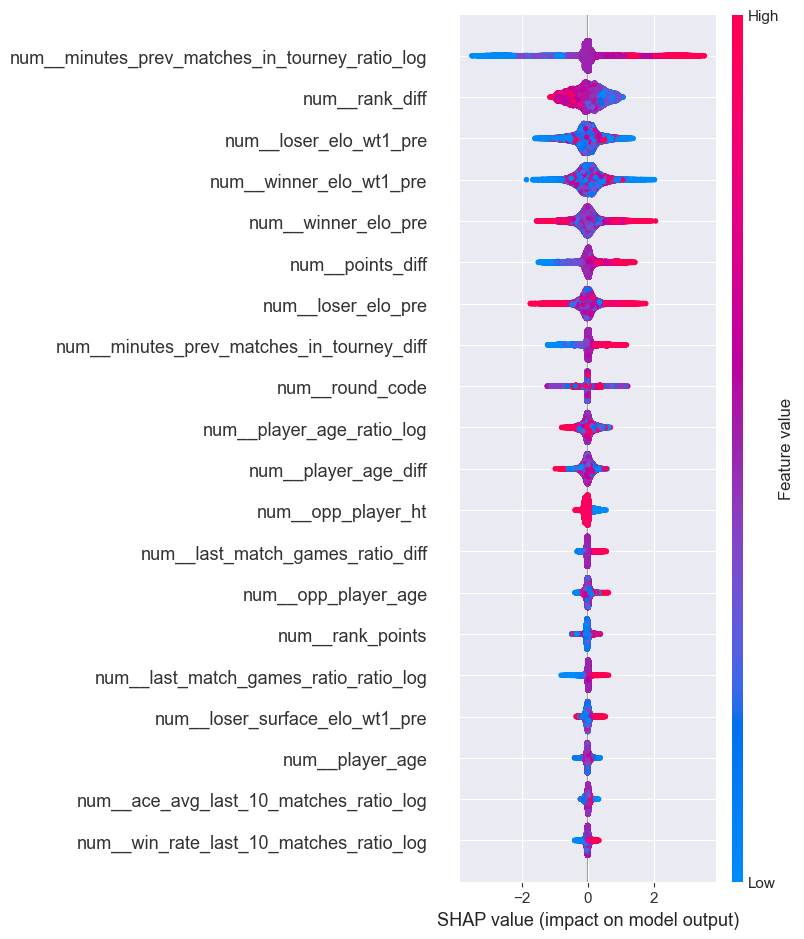

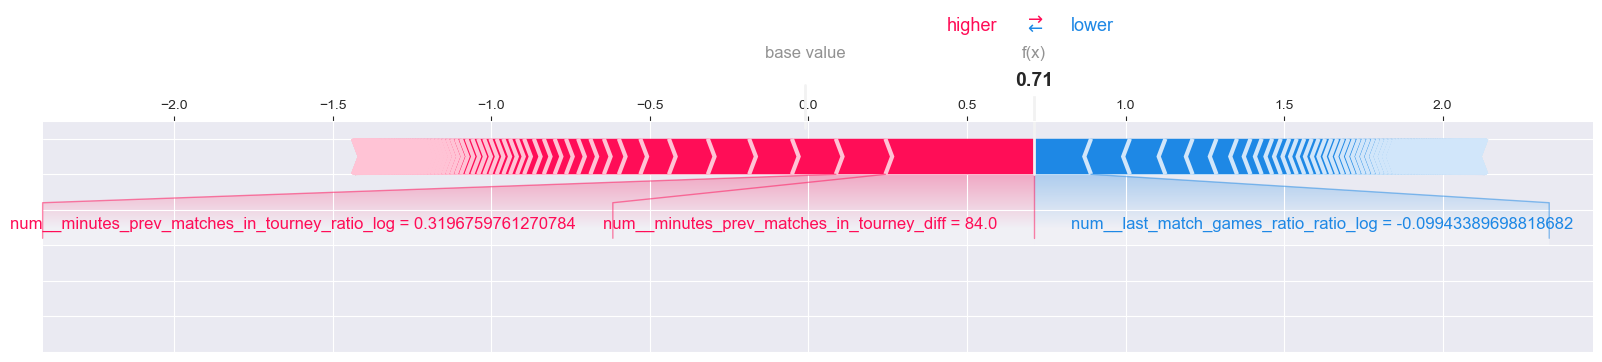

In [190]:
import shap
import matplotlib.pyplot as plt

# 1. 创建解释器（Explainer）
explainer = shap.TreeExplainer(lgbm_clf)

# 2. 计算训练集样本的SHAP值（也可以用测试集）
X_train_processed = pipe.named_steps['preprocessor'].transform(X_train)
shap_values = explainer.shap_values(X_train_processed)

# 3. 绘制全局特征重要性图（summary_plot）
shap.summary_plot(shap_values, X_train_processed, feature_names=pipe.named_steps['preprocessor'].get_feature_names_out())

# 4. 绘制单个样本解释（force_plot）
# 选择一个样本索引，比如第0个
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train_processed[0,:], feature_names=pipe.named_steps['preprocessor'].get_feature_names_out(), matplotlib=True)
plt.show()


In [194]:
all_ranks.head()

,ranking_date,rank,player,points,tours
0,2000-01-01,1,200001,6074.0,NaN
1,2000-01-03,1,200001,6074.0,NaN
2,2000-01-10,1,200001,6074.0,NaN
3,2000-01-17,1,200001,6003.0,NaN
4,2000-01-24,1,200001,6003.0,NaN


In [196]:
import pandas as pd

# 筛选出曾经达到过 Top 30 的 player_id
top30_players = all_ranks.loc[all_ranks['rank'] <= 30, 'player'].unique()

# 从原表中保留这些球员的所有记录
all_rank_top30 = all_ranks[all_ranks['player'].isin(top30_players)].copy()

print(f"共有 {len(top30_players)} 位球员曾进入过 Top 30")


共有 359 位球员曾进入过 Top 30


In [197]:
# 从首次进入100 到 首次进入30的平均分布
import pandas as pd
import matplotlib.pyplot as plt

# 确保日期是 datetime
all_ranks['ranking_date'] = pd.to_datetime(all_ranks['ranking_date'])

# 首次进入 Top 100 的日期
first_top100 = (
    all_ranks.loc[all_ranks['rank'] <= 100]
    .groupby('player')['ranking_date']
    .min()
    .rename('first_top100_date')
)

# 首次进入 Top 30 的日期
first_top30 = (
    all_ranks.loc[all_ranks['rank'] <= 30]
    .groupby('player')['ranking_date']
    .min()
    .rename('first_top30_date')
)

# 合并
df_firsts = pd.concat([first_top100, first_top30], axis=1).dropna()

# 计算时间差
df_firsts['days_to_top30'] = (df_firsts['first_top30_date'] - df_firsts['first_top100_date']).dt.days
df_firsts['months_to_top30'] = df_firsts['days_to_top30'] / 30.44
df_firsts['years_to_top30'] = df_firsts['days_to_top30'] / 365.25

# 查看描述统计
print(df_firsts[['days_to_top30', 'months_to_top30', 'years_to_top30']].describe())



       days_to_top30  months_to_top30  years_to_top30
count     359.000000       359.000000      359.000000
mean      870.905292        28.610555        2.384409
std       838.690974        27.552266        2.296211
min         0.000000         0.000000        0.000000
25%       290.500000         9.543364        0.795346
50%       595.000000        19.546649        1.629021
75%      1260.000000        41.392904        3.449692
max      7147.000000       234.789750       19.567420


In [207]:
Q1 = df_firsts['days_to_top30'].quantile(0.25)
Q3 = df_firsts['days_to_top30'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_firsts[(df_firsts['days_to_top30'] >= lower_bound) & (df_firsts['days_to_top30'] <= upper_bound)].copy()

print(f"去除异常值后，剩余 {len(df_filtered)} 个样本")
# 查看描述统计
print(df_filtered[['days_to_top30', 'months_to_top30', 'years_to_top30']].describe())


去除异常值后，剩余 346 个样本
       days_to_top30  months_to_top30  years_to_top30
count     346.000000       346.000000      346.000000
mean      773.075145        25.396687        2.116564
std       647.449874        21.269707        1.772621
min         0.000000         0.000000        0.000000
25%       274.750000         9.025953        0.752225
50%       581.000000        19.086728        1.590691
75%      1200.500000        39.438239        3.286790
max      2632.000000        86.465177        7.206023


In [198]:
fastest = df_firsts.nsmallest(5, 'days_to_top30')
slowest = df_firsts.nlargest(5, 'days_to_top30')

print("\n最快从Top 100到Top 30的球员：")
print(fastest)

print("\n最慢从Top 100到Top 30的球员：")
print(slowest)



最快从Top 100到Top 30的球员：
       first_top100_date first_top30_date  days_to_top30  months_to_top30  \
player                                                                      
200077        1990-04-09       1990-04-09              0              0.0   
200190        1984-01-09       1984-01-09              0              0.0   
200209        1984-01-02       1984-01-02              0              0.0   
200259        1984-01-02       1984-01-02              0              0.0   
200293        1984-01-02       1984-01-02              0              0.0   

        years_to_top30  
player                  
200077             0.0  
200190             0.0  
200209             0.0  
200259             0.0  
200293             0.0  

最慢从Top 100到Top 30的球员：
       first_top100_date first_top30_date  days_to_top30  months_to_top30  \
player                                                                      
200002        1997-07-07       2017-01-30           7147       234.789750   
201366  

In [199]:
same_day_players = df_firsts[df_firsts['days_to_top30'] == 0].copy()

print(f"共有 {len(same_day_players)} 位球员在首次进入Top100的同一天就进入了Top30")
print(same_day_players)


共有 35 位球员在首次进入Top100的同一天就进入了Top30
       first_top100_date first_top30_date  days_to_top30  months_to_top30  \
player                                                                      
200077        1990-04-09       1990-04-09              0              0.0   
200190        1984-01-09       1984-01-09              0              0.0   
200209        1984-01-02       1984-01-02              0              0.0   
200259        1984-01-02       1984-01-02              0              0.0   
200293        1984-01-02       1984-01-02              0              0.0   
200337        1984-01-02       1984-01-02              0              0.0   
200348        1984-01-02       1984-01-02              0              0.0   
200354        1984-01-02       1984-01-02              0              0.0   
200357        1984-01-02       1984-01-02              0              0.0   
200359        1984-01-02       1984-01-02              0              0.0   
200360        1984-01-02       1984-01-02 

In [201]:
# 从原表取名字
same_day_players = same_day_players.merge(
    all_ranks[['player']].drop_duplicates('player'),
    on='player',
    how='right'
)

print(same_day_players)


    player first_top100_date first_top30_date  days_to_top30  months_to_top30  \
0   200077        1990-04-09       1990-04-09              0              0.0   
1   200190        1984-01-09       1984-01-09              0              0.0   
2   200209        1984-01-02       1984-01-02              0              0.0   
3   200259        1984-01-02       1984-01-02              0              0.0   
4   200293        1984-01-02       1984-01-02              0              0.0   
5   200337        1984-01-02       1984-01-02              0              0.0   
6   200348        1984-01-02       1984-01-02              0              0.0   
7   200354        1984-01-02       1984-01-02              0              0.0   
8   200357        1984-01-02       1984-01-02              0              0.0   
9   200359        1984-01-02       1984-01-02              0              0.0   
10  200360        1984-01-02       1984-01-02              0              0.0   
11  200366        1984-01-02

In [202]:
# 筛选 days_to_top30 == 0 的球员ID
players_same_day = df_firsts.loc[df_firsts['days_to_top30'] == 0].index.tolist()

# 从 all_ranks 中筛选这些球员的全部排名数据
same_day_all_ranks = all_ranks[all_ranks['player'].isin(players_same_day)].copy()

# 按球员和日期排序，方便查看
same_day_all_ranks = same_day_all_ranks.sort_values(by=['player', 'ranking_date'])

print(same_day_all_ranks)


        ranking_date  rank  player  points  tours
1552878   1990-04-09    25  200077    38.0    NaN
1553376   1990-04-16    24  200077    38.0    NaN
1553975   1990-04-23    24  200077    38.0    NaN
1554576   1990-04-30    25  200077    38.0    NaN
1555076   1990-05-07    25  200077    38.0    NaN
...              ...   ...     ...     ...    ...
2035099   2024-12-02    59  221054  1025.0   14.0
2036542   2024-12-09    57  221054  1025.0   14.0
2037997   2024-12-16    57  221054  1025.0   14.0
2039449   2024-12-23    57  221054  1025.0   14.0
2040903   2024-12-30    56  221054  1025.0   14.0

[13002 rows x 5 columns]


In [203]:
same_day_all_ranks.to_csv('D:/2024 Fall Predictive Analytics Diploma/Course/20250717_Project in PA/women-tennis-insights/data/output/players_days_to_top30_0_all_ranks.csv', index=False)

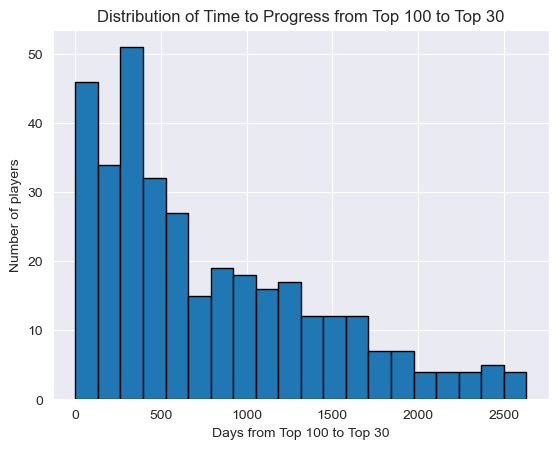

In [208]:
plt.hist(df_filtered['days_to_top30'], bins=20, edgecolor='black')
plt.xlabel('Days from Top 100 to Top 30')
plt.ylabel('Number of players')
plt.title('Distribution of Time to Progress from Top 100 to Top 30')
plt.show()


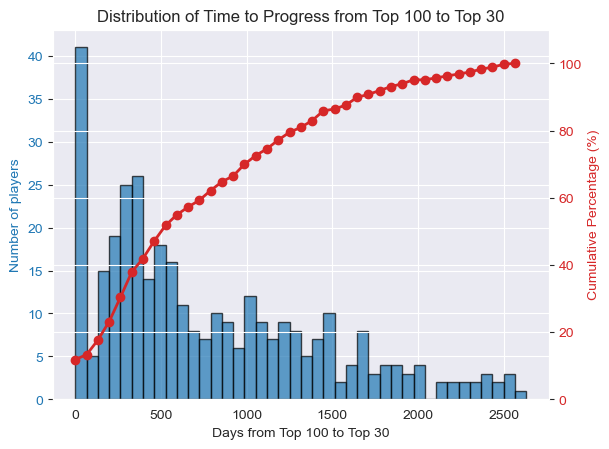

In [210]:
import matplotlib.pyplot as plt
import numpy as np

data = df_filtered['days_to_top30']

fig, ax1 = plt.subplots()

# 画直方图
counts, bins, patches = ax1.hist(data, bins=40, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Days from Top 100 to Top 30')
ax1.set_ylabel('Number of players', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 计算累计百分比
cum_counts = np.cumsum(counts)
cum_percent = cum_counts / cum_counts[-1] * 100

# 画累计百分比曲线
ax2 = ax1.twinx()
ax2.plot(bins[:-1], cum_percent, color='tab:red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 110)  # 让最高接近100%

plt.title('Distribution of Time to Progress from Top 100 to Top 30')
plt.show()


In [211]:
# Top 300 → Top 100 → Top 30 → Top 10 的“生命旅程”

import pandas as pd

def get_first_rank_date(df, rank_threshold=None):
    if rank_threshold is None:
        # 有排名的第一次出现
        return df['ranking_date'].min()
    else:
        # 第一次达到某排名门槛
        sub = df[df['rank'] <= rank_threshold]
        if not sub.empty:
            return sub['ranking_date'].min()
        else:
            return pd.NaT

# 假设 df 是某个球员的所有排名数据（已经按时间排序）
player_groups = all_ranks.groupby('player')

records = []
for player_id, group in player_groups:
    group = group.sort_values('ranking_date')
    first_rank_date = get_first_rank_date(group)
    first_top300_date = get_first_rank_date(group, 300)
    first_top100_date = get_first_rank_date(group, 100)
    first_top30_date = get_first_rank_date(group, 30)
    first_top10_date = get_first_rank_date(group, 10)

    records.append({
        'player': player_id,
        'first_rank_date': first_rank_date,
        'first_top300_date': first_top300_date,
        'first_top100_date': first_top100_date,
        'first_top30_date': first_top30_date,
        'first_top10_date': first_top10_date,
    })

summary_df = pd.DataFrame(records)


              player                first_rank_date  \
count     134.000000                            134   
mean   202754.970149  1998-02-27 15:34:55.522388096   
min    200001.000000            1984-01-02 00:00:00   
25%    200349.500000            1986-07-17 12:00:00   
50%    200992.000000            1998-02-19 12:00:00   
75%    201609.000000            2008-04-19 06:00:00   
max    221103.000000            2018-08-13 00:00:00   
std      4874.506679                            NaN   

                   first_top300_date              first_top100_date  \
count                            134                            134   
mean   1999-03-07 21:29:33.134328320  2000-06-15 04:28:39.402985088   
min              1984-01-02 00:00:00            1984-01-02 00:00:00   
25%              1986-08-28 12:00:00            1987-07-09 12:00:00   
50%              1999-03-01 00:00:00            2000-04-10 00:00:00   
75%              2010-05-06 12:00:00            2012-07-02 00:00:00   
max    

C:\Users\ZhouKan\AppData\Local\Temp\ipykernel_37516\57411057.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


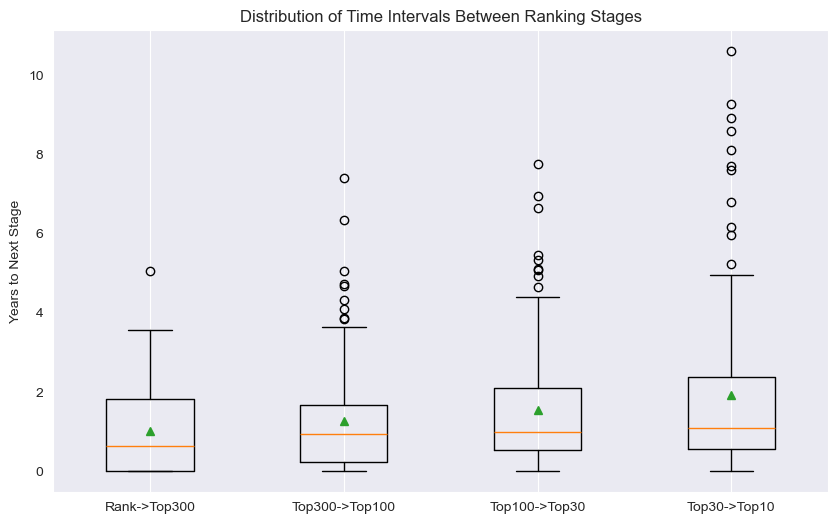

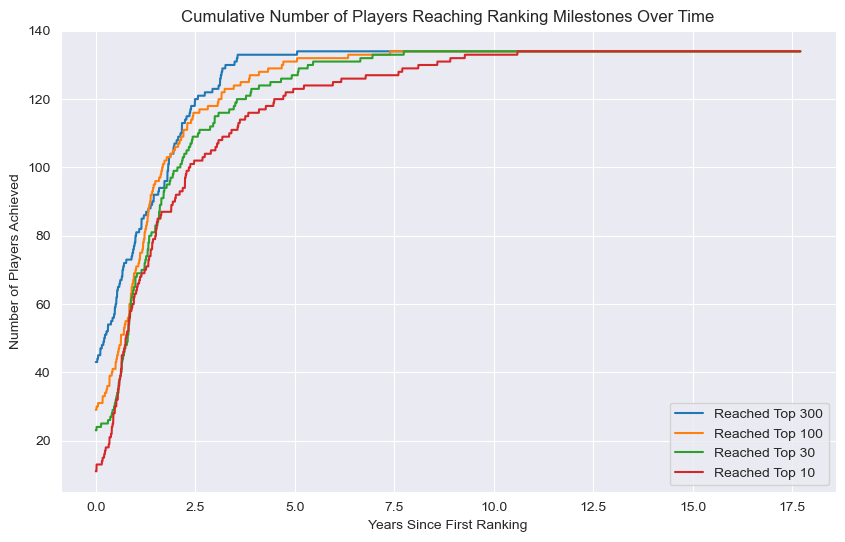

In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 确保日期格式
all_ranks['ranking_date'] = pd.to_datetime(all_ranks['ranking_date'])

# 定义函数：获取首次进入某排名区间的日期
def get_first_rank_date(df, rank_threshold=None):
    if rank_threshold is None:
        # 第一次出现排名
        return df['ranking_date'].min()
    else:
        sub = df[df['rank'] <= rank_threshold]
        if not sub.empty:
            return sub['ranking_date'].min()
        else:
            return pd.NaT

# 分组处理，提取关键时间点
records = []
for player_id, group in all_ranks.groupby('player'):
    group = group.sort_values('ranking_date')
    first_rank_date = get_first_rank_date(group, None)
    first_top300_date = get_first_rank_date(group, 300)
    first_top100_date = get_first_rank_date(group, 100)
    first_top30_date = get_first_rank_date(group, 30)
    first_top10_date = get_first_rank_date(group, 10)

    records.append({
        'player': player_id,
        'first_rank_date': first_rank_date,
        'first_top300_date': first_top300_date,
        'first_top100_date': first_top100_date,
        'first_top30_date': first_top30_date,
        'first_top10_date': first_top10_date,
    })

df_stages = pd.DataFrame(records)

# 只保留有完整阶段数据的球员
df_stages = df_stages.dropna()

# 计算阶段间隔，单位为天
df_stages['days_0_300'] = (df_stages['first_top300_date'] - df_stages['first_rank_date']).dt.days
df_stages['days_300_100'] = (df_stages['first_top100_date'] - df_stages['first_top300_date']).dt.days
df_stages['days_100_30'] = (df_stages['first_top30_date'] - df_stages['first_top100_date']).dt.days
df_stages['days_30_10'] = (df_stages['first_top10_date'] - df_stages['first_top30_date']).dt.days

# 转换为年，方便阅读
for col in ['days_0_300','days_300_100','days_100_30','days_30_10']:
    df_stages[col.replace('days', 'years')] = df_stages[col] / 365.25

print(df_stages.describe())

# 画箱线图展示各阶段晋升时间分布（年）
plt.figure(figsize=(10,6))
plt.boxplot(
    [df_stages['years_0_300'], df_stages['years_300_100'], df_stages['years_100_30'], df_stages['years_30_10']],
    labels=['Rank->Top300', 'Top300->Top100', 'Top100->Top30', 'Top30->Top10'],
    showmeans=True
)
plt.ylabel('Years to Next Stage')
plt.title('Distribution of Time Intervals Between Ranking Stages')
plt.grid(axis='y')
plt.show()

# 画累计人数随时间的趋势图（群体晋升节奏）
plt.figure(figsize=(10,6))
max_days = int((df_stages['first_top10_date'] - df_stages['first_rank_date']).dt.days.max())

# 时间序列（日）
timeline = pd.Series(range(0, max_days + 1))

# 计算每个时间点有多少球员完成对应阶段（以days为标准）
def cumulative_count(stage_days):
    return [ (stage_days <= day).sum() for day in timeline ]

plt.plot(timeline/365.25, cumulative_count(df_stages['days_0_300']), label='Reached Top 300')
plt.plot(timeline/365.25, cumulative_count(df_stages['days_300_100']), label='Reached Top 100')
plt.plot(timeline/365.25, cumulative_count(df_stages['days_100_30']), label='Reached Top 30')
plt.plot(timeline/365.25, cumulative_count(df_stages['days_30_10']), label='Reached Top 10')

plt.xlabel('Years Since First Ranking')
plt.ylabel('Number of Players Achieved')
plt.title('Cumulative Number of Players Reaching Ranking Milestones Over Time')
plt.legend()
plt.grid(True)
plt.show()
